# 05 · AI-Researcher — Can LLMs Generate Novel Research Ideas? A Large-Scale Human Study with 100+ NLP Researchers

**Paper:** Chenglei Si, Diyi Yang, Tatsunori Hashimoto (Stanford). ICLR 2025, arXiv [2409.04109](https://arxiv.org/abs/2409.04109) (`papers/2409.04109.pdf`).

**Code status:** the authors' repository (`github.com/NoviScl/AI-Researcher`, commit `e5dd05a`, MIT licence) ships the complete ideation agent *and* the anonymised human-study reviews. This notebook **drives the vendored repo directly** (`notebooks/vendor/AI-Researcher`, gitignored, re-fetched by the setup cell) after one patch (`notebooks/patches/ai_researcher_openrouter.patch`) that

1. routes every `call_api` through **one** OpenAI-compatible endpoint (`RCP_BASE_URL` / `RCP_MODEL`) instead of separate OpenAI / Anthropic / Together clients, and reports token usage back to `common.USAGE`;
2. makes `keys.json` optional and adds pacing + exponential backoff to the Semantic Scholar calls (the public API is rate-limited and answers 429 without a key), and caps the `GetReferences` fan-out;
3. replaces the `sentence-transformers` (`all-MiniLM-L6-v2`) embedding in the deduplication step — it needs torch, which this notebook must not use — with the OpenAI-compatible `/embeddings` endpoint and a TF-IDF fallback;
4. lifts two pieces of logic out of `__main__`/closures so they can be called and tested from here: the greedy dedup loop (`dedup_ideas.dedup_ideas`) and the Swiss pairing rule (`tournament_ranking.swiss_pairs`), plus a tolerant `parse_choice` for the pairwise judge.

Everything else — every prompt, every threshold — is the authors' code. Glue that is *not* part of the paper's algorithm (parallel drivers, plots, the human-study t-tests) lives in `notebooks/ideation_study.py`.

The paper's agent ran on `claude-3-5-sonnet-20240620` at a scale of **4000 seed ideas per topic**; this notebook runs the same pipeline on `RCP_MODEL` at **~20 seed ideas** on **one** of the paper's seven topics. Absolute numbers are therefore not comparable — the mechanisms and their failure modes are what is under test.

| § | Building block | Paper ref | Repo code |
|---|---|---|---|
| 1 | Related-paper search: `KeywordQuery` / `PaperQuery` / `GetReferences`, LLM relevance scoring 1–10, stop at N papers | §3.1, App. F | `lit_review.collect_papers`, `lit_review_tools.parse_and_execute` |
| 2 | Grounded idea generation: "generate many, then dedup", k=6 demos, RAG on half the batches, no-repeat list | §3.2, App. F/G | `grounded_idea_gen.idea_generation` |
| 3 | Deduplication: pairwise cosine ≥ 0.8 → ~5% survive (200 unique out of 4000) | §3.2, §7.1, Fig. 4, App. H | `dedup_ideas.dedup_ideas`, `analyze_ideas_semantic_similarity` |
| 4 | Project proposal generation: 7-field template | App. B/C | `experiment_plan_gen.plan_generation_method` |
| 5 | Ranking: zero-shot pairwise judge in an N=5 Swiss tournament | §3.3, Table 1, §7.2 Table 11 | `tournament_ranking.{swiss_pairs,better_idea,tournament_ranking}` |
| 6 | Filtering (novelty + feasibility, ~1% filtered) and style normalisation | App. F, App. D | `filter_ideas.*`, `style_transfer.style_transfer` |
| 7 | Mini end-to-end pipeline on a second topic | §3 | all of the above |
| 8 | The human study: novelty of AI vs human ideas (Tables 7–8) | §5.1–§5.2 | `reviews_ideation/stats_overall.py` + shipped review data |

In [1]:
import os, sys, json, time, random, subprocess, textwrap
os.environ.setdefault("TQDM_DISABLE", "1")     # the repo prints tqdm bars inside the tournament
sys.path.insert(0, os.path.abspath("."))
import common
from common import md, show_source, df, QUICK, USAGE, OUTPUT_DIR
import numpy as np
import matplotlib.pyplot as plt
common.banner()

# --- vendor + patch the authors' repo at the pinned commit
COMMIT = "e5dd05a90bcadb436c07283c2f429367c6e525d3"
VENDOR = common.ensure_repo("https://github.com/NoviScl/AI-Researcher", COMMIT, "AI-Researcher")
applied = common.apply_patch("patches/ai_researcher_openrouter.patch", VENDOR)
print("vendored at", VENDOR, "| patch applied now:", applied)
print("licence:", (VENDOR / "LICENSE").read_text().splitlines()[0])

import ideation_study as X
SRC = X.setup(VENDOR)          # puts ai_researcher/src on sys.path, wires the usage tracker
PROMPTS = X.prompts_dir(VENDOR)
OUT = OUTPUT_DIR / "ideation_study"; OUT.mkdir(parents=True, exist_ok=True)

# --- budgets (the paper: 120 papers, 4000 seed ideas, N=5 tournament rounds)
TOPIC_NAME    = "Factuality"
TOPIC         = X.TOPICS[TOPIC_NAME]
MAX_PAPERS    = 12 if QUICK else 25
N_BATCHES     = 2 if QUICK else 4         # x IDEAS_N seed ideas
IDEAS_N       = 5
N_PROPOSALS   = 4 if QUICK else 8
ROUNDS        = 3 if QUICK else 5
SIM_THRESHOLD = 0.8                        # the paper's deduplication threshold
print(f"\ntopic: {TOPIC_NAME} — {TOPIC}")
print(f"budgets: max_paper_bank_size={MAX_PAPERS}, {N_BATCHES}x{IDEAS_N} seed ideas, "
      f"{N_PROPOSALS} proposals, {ROUNDS} tournament rounds")
display(df([{"topic": k, "description": v} for k, v in X.TOPICS.items()]).set_index("topic"))

Model: `deepseek/deepseek-v4-flash` via `https://openrouter.ai/api/v1` · QUICK mode: `False` · outputs → `notebooks/outputs`

vendored at /mnt/berstorage/RCP/rcp-platform/notebooks/vendor/AI-Researcher | patch applied now: False
licence: MIT License

topic: Factuality — novel prompting methods that can improve factuality and reduce hallucination of large language models
budgets: max_paper_bank_size=25, 4x5 seed ideas, 8 proposals, 5 tournament rounds


,description
topic,
Bias,novel prompting methods to reduce social biase...
Coding,novel prompting methods for large language mod...
Safety,novel prompting methods to improve large langu...
Multilingual,novel prompting methods to improve large langu...
Factuality,novel prompting methods that can improve factu...
Math,novel prompting methods for large language mod...
Uncertainty,novel prompting methods that can better quanti...


## 1 · Related-paper search (§3.1, Appendix F)

> "we prompt an LLM to generate a sequence of function calls to the Semantic Scholar API … the action space
> includes: `KeywordQuery(keywords)`, `PaperQuery(paperId)`, and `GetReferences(paperId)`. … We keep the top
> k = 20 papers from each executed function call and stop the action generation when a max of N = 120 papers
> have been retrieved. We then use the LLM to score and rerank all retrieved papers on a scale of 1 to 10."

The three scoring criteria are (1) directly relevant to the topic, (2) an *empirical* paper proposing a method
(surveys / position / analysis papers score low — footnote 3), (3) interesting and able to inspire new projects.
There is no score threshold: the ranked bank is simply passed on. `collect_papers` seeds the bank with a
`KeywordQuery` on the raw topic string, then loops — pick the top-`grounding_k` papers as grounding, ask the LLM
for the next query, execute it, score the new papers — until the bank reaches `max_paper_bank_size`
(or 10 iterations).

In [2]:
import lit_review, lit_review_tools, utils
show_source(lit_review.collect_papers)

**collect_papers**

```python
@retry.retry(tries=3, delay=2)
def collect_papers(topic_description, openai_client, model, seed, grounding_k = 10, max_papers=60, print_all=True, mode = "topic", idea=None):
    paper_bank = {}
    total_cost = 0
    all_queries = []

    ## get initial set of seed papers by KeywordSearch 
    _, query, cost = initial_search(topic_description, openai_client, model, seed, mode=mode, idea=idea)
    total_cost += cost
    all_queries.append(query)
    paper_lst = parse_and_execute(query)
    print ("initial query: ", query)
    print ("paper_lst: ", paper_lst)
    if paper_lst:
        ## filter out those with incomplete abstracts
        paper_lst = [paper for paper in paper_lst if paper["abstract"] and len(paper["abstract"].split()) > 20]
        paper_bank = {paper["paperId"]: paper for paper in paper_lst}

        ## score each paper
        _, response, cost = paper_score(paper_lst, topic_description, openai_client, model, seed, mode=mode, idea=idea)
        total_cost += cost
        response = json.loads(response.strip())

        ## initialize all scores to 0 then fill in gpt4 scores
        for k,v in paper_bank.items():
            v["score"] = 0
        for k,v in response.items():
            try:
                paper_bank[k]["score"] = v
            except:
                continue 
    else:
        paper_lst = []

    ## print stats 
    if print_all:
        print ("initial query: ", query)
        print ("current total cost: ", total_cost)
        print ("current size of paper bank: ", len(paper_bank))
        print_top_papers_from_paper_bank(paper_bank, top_k=10)
        print ("\n")
    
    iter = 0
    ## keep expanding the paper bank until limit is reached
    while len(paper_bank) < max_papers and iter < 10:
        ## select the top k papers with highest scores for grounding
        data_list = [{'id': id, **info} for id, info in paper_bank.items()]
        grounding_papers = sorted(data_list, key=lambda x: x['score'], reverse=True)[ : grounding_k]
        
        ## generate the next query
        _, new_query, cost = next_query(topic_description, openai_client, model, seed, grounding_papers, all_queries, mode=mode, idea=idea)
        all_queries.append(new_query)
        total_cost += cost 
        if print_all:
            print ("new query: ", new_query)
        try:
            paper_lst = parse_and_execute(new_query)
        except:
            paper_lst = None 
        
        if paper_lst:
            ## filter out papers already in paper bank 
            paper_lst = [paper for paper in paper_lst if paper["abstract"] and len(paper["abstract"].split()) > 50]
            paper_lst = [paper for paper in paper_lst if paper["paperId"] not in paper_bank]
            
            ## initialize all scores to 0 and add to paper bank
            for paper in paper_lst:
                paper["score"] = 0
            paper_bank.update({paper["paperId"]: paper for paper in paper_lst})
            
            ## gpt4 score new papers
            _, response, cost = paper_score(paper_lst, topic_description, openai_client, model, seed, mode=mode, idea=idea)
            total_cost += cost
            response = json.loads(response.strip())
            for k,v in response.items():
                try:
                    paper_bank[k]["score"] = v
                except:
                    continue

        elif print_all:
            print ("No new papers found in this round.")
        
        ## print stats 
        if print_all:
            print ("current total cost: ", total_cost)
            print ("current size of paper bank: ", len(paper_bank))
            print_top_papers_from_paper_bank(paper_bank, top_k=10)
            print ("\n")
        
        iter += 1
    
    ## rank all papers by score
    data_list = [{'id': id, **info} for id, info in paper_bank.items()]
    sorted_data = sorted(data_list, key=lambda x: x['score'], reverse=True)
    sorted_data = dedup_paper_bank(sorted_data)

    return sorted_data, total_cost, all_queries

```

In [3]:
md("**The action space** — the parser that turns the LLM's one-line reply into a Semantic Scholar call:")
show_source(lit_review_tools.parse_and_execute)

**The action space** — the parser that turns the LLM's one-line reply into a Semantic Scholar call:

**parse_and_execute**

```python
def parse_and_execute(output):
    ## parse gpt4 output and execute corresponding functions
    if output.startswith("KeywordQuery"):
        match = re.match(r'KeywordQuery\("([^"]+)"\)', output)
        keyword = match.group(1) if match else None
        if keyword:
            response = KeywordQuery(keyword)
            if response is None:
                return None
            if 'total' in response and response['total'] == 0:
                return None
            if response is not None:
                if "data" in response:
                    paper_lst = response["data"]
                else:
                    paper_lst = response[:]
                return paper_filter(paper_lst)
    elif output.startswith("PaperQuery"):
        match = re.match(r'PaperQuery\("([^"]+)"\)', output)
        paper_id = match.group(1) if match else None
        if paper_id:
            response = PaperQuery(paper_id)
            if response is not None and response["recommendedPapers"]:
                paper_lst = response["recommendedPapers"]
                return paper_filter(paper_lst)
    elif output.startswith("GetAbstract"):
        match = re.match(r'GetAbstract\("([^"]+)"\)', output)
        paper_id = match.group(1) if match else None
        if paper_id:
            return GetAbstract(paper_id)
    elif output.startswith("GetCitationCount"):
        match = re.match(r'GetCitationCount\("([^"]+)"\)', output)
        paper_id = match.group(1) if match else None
        if paper_id:
            return GetCitationCount(paper_id)
    elif output.startswith("GetCitations"):
        match = re.match(r'GetCitations\("([^"]+)"\)', output)
        paper_id = match.group(1) if match else None
        if paper_id:
            return GetCitations(paper_id)
    elif output.startswith("GetReferences"):
        match = re.match(r'GetReferences\("([^"]+)"\)', output)
        paper_id = match.group(1) if match else None
        if paper_id:
            return GetReferences(paper_id)
    
    return None

```

In [4]:
X.set_tag("lit_review")
t0 = time.time(); calls0 = USAGE.requests
PAPER_BANK, lit_cost, ALL_QUERIES = lit_review.collect_papers(
    TOPIC, None, "rcp", seed=2024, grounding_k=10, max_papers=MAX_PAPERS, print_all=False, mode="topic")
if not PAPER_BANK:
    # The unauthenticated Semantic Scholar endpoint shares one rate limit across all anonymous
    # callers; if every query in the loop was answered with 429 the bank comes back empty.
    print("paper bank empty (Semantic Scholar rate limit) -- retrying the search once\n")
    PAPER_BANK, lit_cost, ALL_QUERIES = lit_review.collect_papers(
        TOPIC, None, "rcp", seed=7, grounding_k=10, max_papers=MAX_PAPERS, print_all=False, mode="topic")
print(f"{len(PAPER_BANK)} papers in {time.time()-t0:.0f}s using {USAGE.requests - calls0} LLM calls\n")
print("queries the LLM proposed, in order:")
for q in ALL_QUERIES: print("   ", q)
LIT_CACHE = {"topic_description": TOPIC, "all_queries": ALL_QUERIES, "paper_bank": PAPER_BANK, "total_cost": lit_cost}
(OUT / "lit_review").mkdir(exist_ok=True)
(OUT / "lit_review" / "factuality_prompting_method.json").write_text(json.dumps(LIT_CACHE, indent=2))
display(df(X.paper_rows(PAPER_BANK, 10)))

[S2] status 429, retry 1/8 in 1.6s


[S2] status 429, retry 2/8 in 2.6s


[S2] status 429, retry 3/8 in 4.7s


[S2] status 429, retry 4/8 in 8.7s


[S2] status 429, retry 5/8 in 16.5s


...

[S2] status 429, retry 3/8 in 4.4s


[S2] status 429, retry 4/8 in 9.0s


[S2] status 429, retry 5/8 in 16.7s


37 papers in 864s using 10 LLM calls

queries the LLM proposed, in order:
    KeywordQuery("novel prompting methods that can improve factuality and reduce hallucination of large language models")
    KeywordQuery("chain-of-thought prompting hallucination factuality")
    KeywordQuery("multi-agent debate factuality hallucination")
    KeywordQuery("retrieval augmented generation factuality hallucination")
    KeywordQuery("prompting strategies factual consistency LLM")
    KeywordQuery("self-consistency prompting factual accuracy")
    KeywordQuery("knowledge graph prompting hallucination")
    KeywordQuery("prompt engineering factuality hallucination")


,score,year,cites,title
0,8,2024,60,KG-CoT: Chain-of-Thought Prompting of Large La...
1,8,2025,8,Adaptive heterogeneous multi-agent debate for ...
2,7,2025,0,Aligning Medical Images and Language Through M...
3,7,2026,0,CSMAD: Hallucination Detection via Multi-Agent...
4,6,2026,0,Retrieval-Augmented Large Language Models for ...
5,6,2025,0,Enhancing Hallucination Detection in Large Lan...
6,5,2026,1,CARMINA: optimizing low-parameter language mod...
7,4,2026,0,Prompt Engineering Based Factivity Hallucinati...
8,3,2025,22,Mitigating spatial hallucination in large lang...
9,3,2025,1,LLM Enhancement with Domain Expert Mental Mode...


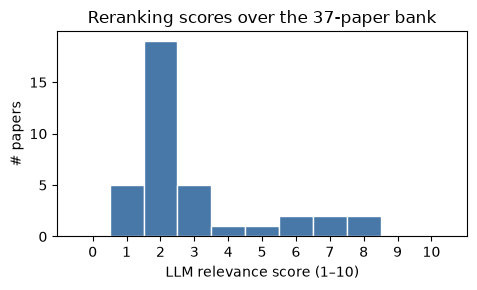

score distribution: {1: 5, 2: 19, 3: 5, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2}
score 0 = the paper was retrieved but missing from the scorer's JSON reply (the repo defaults it to 0)


In [5]:
scores = [int(p.get("score") or 0) for p in PAPER_BANK]
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(scores, bins=np.arange(-0.5, 11.5, 1), color="#4878a8", edgecolor="white")
ax.set(xlabel="LLM relevance score (1–10)", ylabel="# papers", xticks=range(0, 11),
       title=f"Reranking scores over the {len(PAPER_BANK)}-paper bank")
plt.tight_layout(); plt.show()
print("score distribution:", {s: scores.count(s) for s in sorted(set(scores))})
print("score 0 = the paper was retrieved but missing from the scorer's JSON reply (the repo defaults it to 0)")

### The other two actions

The run above only exercised the actions the LLM happened to choose. `PaperQuery` (Semantic Scholar's
*recommendations* endpoint) and `GetReferences` (fetch the reference list, then the details of each reference)
are driven here by hand on the top-scoring paper. `GetReferences` costs one request per reference, so the patch
caps the fan-out (`S2_MAX_REFERENCES`); the paper's own runs used an API key and no cap.

In [6]:
lit_review_tools.S2_MAX_REFERENCES = 6      # patched knob: 6 detail requests instead of up to 100
if not PAPER_BANK:
    print("no papers retrieved, so there is no seed paperId to drive PaperQuery/GetReferences with")
else:
    top = PAPER_BANK[0]
    print("seed paper:", top["title"], "|", top["paperId"], "\n")
    for action in (f'PaperQuery("{top["paperId"]}")', f'GetReferences("{top["paperId"]}")'):
        t0 = time.time()
        result = lit_review_tools.parse_and_execute(action)
        n = len(result) if result else 0
        print(f"{action[:40]:<42} -> {n} papers in {time.time()-t0:.0f}s")
        for p in (result or [])[:3]:
            print("      ", (p.get("title") or "")[:90])
print("\nNote on the action loop: `next_query` is grounded on the papers already in the bank. When a "
      "round returns nothing (a 429, or a query with no hits) the model has nothing to ground on and "
      "tends to invent paperIds for PaperQuery -- visible in the query list above if it happened here.")

seed paper: KG-CoT: Chain-of-Thought Prompting of Large Language Models over Knowledge Graphs for Knowledge-Aware Question Answering | 4c0f029efd5371eed087d0794fb0df71238600cc 



PaperQuery("4c0f029efd5371eed087d0794fb0   -> 20 papers in 1s
       Are reasoning paradigms scale-aware? A cross-paradigm verification of prompting, retrieval
       KGP-QG: Multi-hop Reasoning with Knowledge Graphs in LLMs
       Debate-on-Graph: Reliable and Adaptive Reasoning of Large Language Model on Uncertain Know


GetReferences("4c0f029efd5371eed087d0794   -> 0 papers in 2s

Note on the action loop: `next_query` is grounded on the papers already in the bank. When a round returns nothing (a 429, or a query with no hits) the model has nothing to ground on and tends to invent paperIds for PaperQuery -- visible in the query list above if it happened here.


## 2 · Grounded idea generation (§3.2, Appendix F/G)

> "our key insight is … to generate as many candidate ideas as possible … only a small fraction of them might be
> high-quality … We generate 4000 seed ideas on each research topic."

Each call asks for a small batch (the repo recommends `ideas_n=5`) because "short ideas are generated first due to
the max output length limit of the LLM API … so that we can explore more different ideas given the same output
token budget". Three things are put in the prompt: **k = 6 demonstration ideas** hand-written from exemplar papers,
**k = 10 retrieved papers** sampled from the top 20 of §1 (retrieval augmentation is applied to *half* the batches,
deliberately, to widen the distribution), and **the titles of all previously generated ideas** with an instruction
not to repeat them. The seed-idea format is a JSON dict `{idea name: {Problem, Existing Methods, Motivation,
Proposed Method, Experiment Plan}}`.

In [7]:
import grounded_idea_gen
show_source(grounded_idea_gen.idea_generation)

**idea_generation**

```python
@retry.retry(tries=3, delay=2)
def idea_generation(method, existing_ideas, paper_bank, grounding_k, examples, ideas_n, topic_description, openai_client, model, seed, temperature, top_p, max_tokens, RAG=True):
    ## retrieve top papers (with some randomization)
    top_papers = paper_bank[ : int(grounding_k * 2)]
    random.shuffle(top_papers)
    grounding_papers = top_papers[ : grounding_k]

    prompt = "You are an expert researcher in AI. Now I want you to help me brainstorm some new research project ideas on the topic of: " + topic_description + ".\n\n"
    if RAG:
        prompt += "Here are some relevant papers on this topic just for your background knowledge:\n" + format_papers_for_printing(grounding_papers, include_score=False, include_id=False) + "\n"
    prompt += "You should generate {} different ideas on this topic. Try to be creative and diverse in the idea generation, and do not repeat any similar ideas. ".format(str(ideas_n))
    if RAG:
        prompt += "The above papers are only for inspiration and you should not cite them and just make some incremental modifications. Instead, you should make sure your ideas are novel and distinct from the prior literature. "
    prompt += "You should aim for projects that can potentially win best paper awards at top AI conferences like ACL and NeurIPS.\n"
    prompt += "Each idea should be described as: (1) Problem: State the problem statement, which should be closely related to the topic description and something that large language models cannot solve well yet. (2) Existing Methods: Mention some existing benchmarks and baseline methods if there are any. (3) Motivation: Explain the inspiration of the proposed method and why it would work well. (4) Proposed Method: Propose your new method and describe it in detail. The proposed method should be maximally different from all existing work and baselines, and be more advanced and effective than the baselines. You should be as creative as possible in proposing new methods, we love unhinged ideas that sound crazy. This should be the most detailed section of the proposal. (5) Experiment Plan: Specify the experiment steps, baselines, and evaluation metrics.\n"
    prompt += "You can follow these examples to get a sense of how the ideas should be formatted (but don't borrow the ideas themselves):\n" + examples + "\n"
    prompt += "You should make sure to come up with your own novel and different ideas for the specified problem: " + topic_description + ". You should try to tackle important problems that are well recognized in the field and considered challenging for current models. For example, think of novel solutions for problems with existing benchmarks and baselines. In rare cases, you can propose to tackle a new problem, but you will have to justify why it is important and how to set up proper evaluation.\n"
    if "claude" in model:
        prompt += "You should make each idea standalone and not dependent on the other ideas.\n"
    if method == "prompting":
        prompt += "Focus on novel prompting ideas for now. The proposed method section should specify how to construct the prompts for all steps involved. Try to avoid large-scale pretraining experiments or human studies.\n"
    elif method == "finetuning":
        prompt += "Focus on novel finetuning ideas for now. The proposed method section should specify how to get the finetuning data and what's the training objective.\n"
    else:
        prompt += "Focus on proposing novel empirical methods, which can include prompting, finetuning, inference-time interventions, etc. The proposed method section should specify all the details involved, such as how to get the data, what's the training objective, how to construct the prompts, etc.\n"
    if existing_ideas:
        prompt += "You should avoid repeating the following existing ideas and try to be different and diverse: " + existing_ideas + "\n"
    prompt += "Please write down your {} ideas (each idea should be described as one paragraph. Output the ideas in json format as a dictionary, where you should generate a short idea name (e.g., \"Non-Linear Story Understanding\", or \"Multi-Agent Negotiation\") as the key and the actual idea description as the value (following the above format). Do not repeat idea names or contents.".format(str(ideas_n))

    prompt_messages = [{"role": "user", "content": prompt}]
    response, cost = call_api(openai_client, model, prompt_messages, temperature=temperature, top_p=top_p, max_tokens=max_tokens, seed=seed, json_output=True)
    return prompt, response, cost

```

In [8]:
DEMOS = utils.shuffle_dict_and_convert_to_string(json.loads((PROMPTS / "idea_examples_prompting_method.json").read_text()))
print(f"{len(json.loads(DEMOS))} demonstration ideas, {len(DEMOS)} chars. First one:\n")
first = json.loads(DEMOS); k0 = list(first)[0]
print(k0); print(json.dumps(first[k0], indent=1)[:900], "...")

6 demonstration ideas, 9669 chars. First one:

According-to Prompting
{
 "Problem": "Large Language Models may hallucinate and generate fake information on factual QA tasks.",
 "Existing Methods": "For factual QA tasks, a typical baseline is to directly prompt large language models with the question and ask for an answer.",
 "Motivation": "Large language models have already been pretrained on massive amount of factual data. We can potentially improve their factuality by encouraging them to quote directly from underlying trusted resources seen during training.",
 "Proposed Method": "We propose according-to prompting: directing LLMs to ground responses against previously observed text by prepending instructions like \"According to Wikipedia,\" and letting the models quote from Wikipedia when generating the answer.",
 "Experiment Plan": "Compare the proposed method with the baseline of direct prompting on several factual QA tasks to see whether according-to p ...


In [9]:
X.set_tag("idea_gen")
t0 = time.time(); calls0 = USAGE.requests
BATCHES = X.generate_seed_ideas(PAPER_BANK, DEMOS, TOPIC, n_batches=N_BATCHES, ideas_n=IDEAS_N,
                                grounding_k=10, max_tokens=6000, temperature=1.0, workers=N_BATCHES)
NAMES, VALUES = X.flatten_ideas(BATCHES)
print(f"\n{len(NAMES)} seed ideas from {N_BATCHES} batches "
      f"(RAG on batches {[i+1 for i in range(N_BATCHES) if i % 2 == 0]}) "
      f"in {time.time()-t0:.0f}s / {USAGE.requests - calls0} calls")
display(df([{"batch": b + 1, "idea name": k, "words": len(json.dumps(v).split())}
            for b, batch in enumerate(BATCHES) for k, v in batch.items()]))

[warning] response hit max_tokens and was truncated
[idea_gen] batch 4: truncated JSON at 6000 tokens, retrying with 12000



20 seed ideas from 4 batches (RAG on batches [1, 3]) in 467s / 5 calls


,batch,idea name,words
0,1,Epistemic Uncertainty Prompting,376
1,1,Recursive Counterfactual Prompting,366
2,1,Stochastic Re-Birth Prompting,427
3,1,Temporal Identity Prompting,449
4,1,Adversarial Symbiote Prompting,474
5,2,Counterfactual Consistency Prompting,542
6,2,Adversarial Reflection Prompting,485
7,2,Temporal Consistency Prompting,492
8,2,Epistemic Uncertainty Prompting via Counterfac...,546
9,2,Multi-Agent Role-Play with Adversarial Hackers,649


In [10]:
md("**Seed-idea JSON format** (Appendix G) — one idea verbatim:")
print(json.dumps({NAMES[0]: VALUES[0]}, indent=2))
print("\nfields present in every idea:", sorted({f for v in VALUES if isinstance(v, dict) for f in v}))

**Seed-idea JSON format** (Appendix G) — one idea verbatim:

{
  "Epistemic Uncertainty Prompting": {
    "Problem": "Large language models often generate confident-sounding hallucinations even when they lack knowledge, failing to distinguish between known, uncertain, and unknown claims. Current models produce plausible but false information without internally signaling their own epistemic limits.",
    "Existing Methods": "Existing methods include chain-of-verification, self-refine, and calibrated confidence estimation via logit analysis or ensemble sampling. These approaches treat uncertainty post-hoc or require external verification, but do not explicitly leverage the model's own latent representations of knowledge boundaries.",
    "Motivation": "Inspired by Bayesian epistemology and human metacognition, we hypothesize that LLMs internally encode degrees of belief across multiple latent pathways, but current prompting methods force them into single-path deterministic outputs. By prompting the model to explicitly reason about its own uncertai

## 3 · Deduplication (§3.2, §7.1, Fig. 4, Appendix H)

> "We encode all seed ideas with all-MiniLM-L6-v2 from Sentence-Transformers and compute pairwise cosine
> similarities. We set a similarity threshold of 0.8 for the idea deduplication based on manual inspection."

The consequence is §7.1, the paper's sharpest negative result: **"out of the 4000 generated seed ideas, there are
only 200 non-duplicate unique ideas"** — about 5% — and the accumulated-unique curve plateaus, so "increasing the
number of generated ideas simply leads to repeating duplicate ideas". The filter itself is a greedy first-wins
sweep: walk the ideas in order, keep the first, mark every later idea above the threshold as a duplicate.

**Deviation:** `all-MiniLM-L6-v2` requires torch, which this environment reserves for another notebook, so the
patch swaps in the OpenAI-compatible `/embeddings` endpoint (`openai/text-embedding-3-small`) with a TF-IDF
fallback. The 0.8 threshold was calibrated *for MiniLM* — the sweep below shows why that matters.

In [11]:
import dedup_ideas
show_source(dedup_ideas.dedup_ideas)
show_source(dedup_ideas.concatenate_idea)

**dedup_ideas**

```python
def dedup_ideas(all_ideas, all_idea_ks, all_idea_vs, similarity_matrix, similarity_threshold=0.8):
    """Greedy first-wins deduplication (the repo's exact loop, lifted out of __main__).

    Walk the ideas in order; keep an idea if it has not already been filtered, then mark every
    later idea that is above the cosine threshold (or shares its name) as a duplicate.
    Returns (final_ideas, filter_idx).

    NOTE: the `and`/`or` precedence in the original condition is preserved verbatim -- it reads
    ``(j not in filter_idx and sim > thr) or (name_j == name_i)``, so a name collision filters
    idea j even if j was already in filter_idx (harmless: it is appended twice).
    """
    final_ideas = {}
    filter_idx = []   ## ideas that should be filtered
    for i in tqdm(range(len(all_ideas))):
        if i not in filter_idx:
            ## add current idea to filtered_ideas
            final_ideas[all_idea_ks[i]] = all_idea_vs[i]

            ## filter out similar ideas
            for j in range(i+1, len(all_ideas)):
                if j not in filter_idx and similarity_matrix[i][j] > similarity_threshold or all_idea_ks[j] == all_idea_ks[i]:
                    filter_idx.append(j)
    return final_ideas, filter_idx

```

**concatenate_idea**

```python
def concatenate_idea(idea_k, idea_v):
    output = ""
    output += idea_k + "\n"
    
    if isinstance(idea_v, dict):
        output += "Problem: " + idea_v["Problem"] + "\n"
        output += "Existing Methods: " + idea_v["Existing Methods"] + "\n"
        output += "Motivation: " + idea_v["Motivation"] + "\n"
        output += "Proposed Method: " + idea_v["Proposed Method"] + "\n"
        output += "Experiment Plan: " + idea_v["Experiment Plan"] + "\n"
    else:
        output += str(idea_v) + "\n"

    return output

```

1 idea(s) dropped before deduplication because the model omitted one of the five seed-idea fields (the repo silently skips these): ['Socratic Refutation Prompting']


embedding backend actually used: openai/text-embedding-3-small   (paper: sentence-transformers all-MiniLM-L6-v2)
similarity matrix (19, 19), diagonal zeroed as in the repo


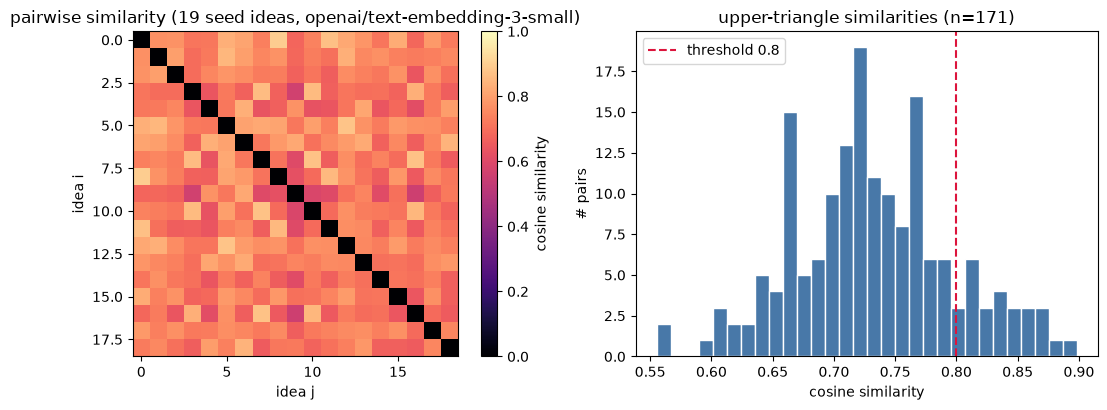

mean pairwise cosine 0.731, max 0.898, 25 of 171 pairs above 0.8


In [12]:
TEXTS, NAMES, VALUES, DROPPED = X.concat_ideas(NAMES, VALUES)
if DROPPED:
    print(f"{len(DROPPED)} idea(s) dropped before deduplication because the model omitted one of the five "
          f"seed-idea fields (the repo silently skips these): {DROPPED}")
SIM, BACKEND = utils.rcp_similarity_matrix(TEXTS)
print(f"embedding backend actually used: {BACKEND}   (paper: sentence-transformers all-MiniLM-L6-v2)")
print(f"similarity matrix {SIM.shape}, diagonal zeroed as in the repo")
X.plot_similarity(SIM, threshold=SIM_THRESHOLD, title=f"({len(TEXTS)} seed ideas, {BACKEND})")
iu = np.triu_indices(len(SIM), k=1)
print(f"mean pairwise cosine {SIM[iu].mean():.3f}, max {SIM[iu].max():.3f}, "
      f"{(SIM[iu] > SIM_THRESHOLD).sum()} of {len(iu[0])} pairs above {SIM_THRESHOLD}")

In [13]:
KEPT, FILTERED = dedup_ideas.dedup_ideas(TEXTS, NAMES, VALUES, SIM, similarity_threshold=SIM_THRESHOLD)
print(f"{len(TEXTS)} seed ideas -> {len(KEPT)} survive at threshold {SIM_THRESHOLD} "
      f"({100*len(KEPT)/len(TEXTS):.0f}% vs the paper's ~5% at 4000 ideas)")
print("removed:", sorted({NAMES[j] for j in FILTERED}) or "none")
nn = [(NAMES[i], NAMES[int(np.argmax(SIM[i]))], float(SIM[i].max())) for i in range(len(SIM))]
display(df([{"idea": a, "nearest neighbour": b, "cosine": round(c, 3), "> 0.8": c > SIM_THRESHOLD}
            for a, b, c in sorted(nn, key=lambda t: -t[2])[:10]]))

19 seed ideas -> 9 survive at threshold 0.8 (47% vs the paper's ~5% at 4000 ideas)
removed: ['Adversarial Reflection Prompting', 'Counterfactual Consistency Prompting', 'Counterfactual-Sensitivity Prompting', 'Crowd-Within Prompting', 'Entropy-Guided Hallucination Probe Prompting', 'Epistemic Uncertainty Prompting via Counterfactual Self-Explanation', 'Epistemic-Doubt Prompting', 'Temporal Consistency Constraint Prompting', 'Temporal Consistency Prompting', 'Temporal-Consistency Prompting']


,idea,nearest neighbour,cosine,> 0.8
0,Epistemic Uncertainty Prompting,Epistemic Uncertainty Prompting via Counterfac...,0.898,True
1,Epistemic Uncertainty Prompting via Counterfac...,Epistemic Uncertainty Prompting,0.898,True
2,Counterfactual Consistency Prompting,Counterfactual-Sensitivity Prompting,0.879,True
3,Counterfactual-Sensitivity Prompting,Counterfactual Consistency Prompting,0.879,True
4,Temporal Consistency Prompting,Temporal-Consistency Prompting,0.874,True
5,Temporal-Consistency Prompting,Temporal Consistency Prompting,0.874,True
6,Temporal Consistency Constraint Prompting,Temporal Consistency Prompting,0.873,True
7,Epistemic-Doubt Prompting,Epistemic Uncertainty Prompting,0.868,True
8,Temporal Identity Prompting,Temporal Consistency Prompting,0.860,True
9,Recursive Counterfactual Prompting,Counterfactual Consistency Prompting,0.848,True


**Threshold sweep** — how many of the same ideas survive as the threshold moves (the paper's value is 0.8):

,#kept,#removed
threshold,,
0.50,1,18
0.60,1,18
0.70,3,16
0.75,4,15
0.80,9,10
0.85,14,5
0.90,19,0
0.95,19,0


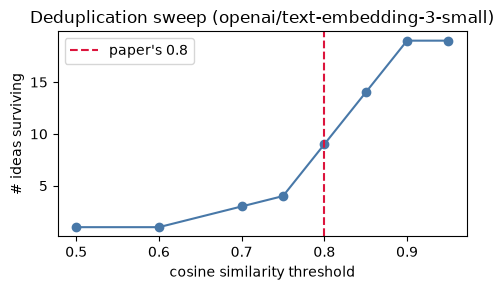

In [14]:
md("**Threshold sweep** — how many of the same ideas survive as the threshold moves (the paper's value is 0.8):")
sweep = X.threshold_sweep(NAMES, VALUES, TEXTS, SIM, [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])
display(df(sweep).set_index("threshold"))
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot([r["threshold"] for r in sweep], [r["#kept"] for r in sweep], "o-", color="#4878a8")
ax.axvline(SIM_THRESHOLD, color="crimson", ls="--", label="paper's 0.8")
ax.set(xlabel="cosine similarity threshold", ylabel="# ideas surviving",
       title=f"Deduplication sweep ({BACKEND})"); ax.legend(); plt.tight_layout(); plt.show()

### Calibrating the threshold on hand-built near-duplicates

Appendix H prints three sampled seed ideas next to their nearest neighbours with similarities **0.70, 0.77 and
0.81** — i.e. 0.8 sits right on the boundary between "related" and "the same idea" *for MiniLM*. Below we feed the
matcher four hand-written variants of one real seed idea: a verbatim copy, a paraphrase, a same-mechanism
rewrite, and a genuinely different idea. No LLM call is involved — this is a check of the deterministic filter.

In [15]:
base = TEXTS[0]
probes = {
    "original":            base,
    "verbatim copy":       base,
    "paraphrase":          base.replace("large language models", "LLMs").replace("Proposed Method", "Method We Propose").replace("we ", "the system "),
    "same idea, rewritten": "Rewritten Variant\n" + " ".join(base.split()[::1][:60]) + " In other words, the model is asked to verify its own claims before answering, which is exactly the mechanism above.",
    "different idea":      "Curriculum Temperature Sampling\nProblem: multilingual code translation degrades on low-resource languages.\nProposed Method: schedule the decoding temperature by token entropy across a curriculum of language pairs.\nExperiment Plan: evaluate on FLORES-200 and MBPP-X with chrF and pass@1.",
}
psim, _ = utils.rcp_similarity_matrix(list(probes.values()))
rows = [{"probe": k, "cosine vs original": round(float(psim[0][i]), 3),
         "duplicate at 0.8": bool(psim[0][i] > SIM_THRESHOLD)} for i, k in enumerate(probes) if i > 0]
display(df(rows).set_index("probe"))
print("(a verbatim copy has cosine 1.0 by construction; the diagonal is zeroed, hence row 0 vs column 1)")

,cosine vs original,duplicate at 0.8
probe,,
verbatim copy,1.000,True
paraphrase,0.997,True
"same idea, rewritten",0.756,False
different idea,0.355,False


(a verbatim copy has cosine 1.0 by construction; the diagonal is zeroed, hence row 0 vs column 1)


### The repo's own CLI, end to end

`scripts/dedup_ideas.sh` is two scripts: `analyze_ideas_semantic_similarity.py --save_similarity_matrix` writes
`<cache>_similarity_matrix.npy`, then `dedup_ideas.py` applies the threshold. Both are run here as subprocesses on
the seed ideas from §2, to show the patched command line works unmodified (their embedding calls are billed to the
same key but are not visible to `USAGE`, which only tracks chat completions in-process).

In [16]:
seed_dir = OUT / "seed_ideas"; seed_dir.mkdir(exist_ok=True)
(seed_dir / "factuality_prompting_method.json").write_text(json.dumps({"topic_description": TOPIC, "ideas": BATCHES}, indent=2))
env = {**os.environ, "PYTHONPATH": str(SRC)}
for script, extra in [("analyze_ideas_semantic_similarity.py", ["--save_similarity_matrix"]),
                      ("dedup_ideas.py", ["--dedup_cache_dir", str(OUT / "ideas_dedup"),
                                          "--similarity_threshold", str(SIM_THRESHOLD)])]:
    cmd = [sys.executable, str(SRC / script), "--cache_dir", str(seed_dir) + "/",
           "--cache_name", "factuality_prompting_method"] + extra
    r = subprocess.run(cmd, capture_output=True, text=True, cwd=str(VENDOR / "ai_researcher"), env=env)
    print("$", script, " ".join(extra))
    print(textwrap.indent("\n".join([l for l in (r.stdout + r.stderr).splitlines() if l.strip()][-8:]), "    "))
DEDUPED = json.loads((OUT / "ideas_dedup" / "factuality_prompting_method.json").read_text())
print("\nCLI kept", len(DEDUPED["ideas"]), "ideas; in-process call kept", len(KEPT), "->",
      "same" if set(DEDUPED["ideas"]) == set(KEPT) else "DIFFERENT (embeddings are not deterministic run to run)")

$ analyze_ideas_semantic_similarity.py --save_similarity_matrix
    and
    Temporal-Consistency Prompting
    Problem: Large language models hallucinate when generating factual statements about events that unfold over time, failing to maintain temporal consistency across multiple statements (e.g., misordering cause and effect, claiming an event occurred before its precursor).
    Existing Methods: Current methods like Chain-of-Thought, self-consistency, and retrieval-augmented generation do not explicitly enforce temporal ordering constraints. FactScore and TempLAMA benchmarks measure factuality and temporal reasoning, but baselines still struggle with multi-step temporal narratives.
    Motivation: Inspired by how humans mentally timestamp events and enforce chronological coherence, LLMs can be prompted to generate internal temporal markers and cross-check them. By forcing the model to explicitly declare and verify temporal relationships, we can reduce timeline-based hallucinations w

$ dedup_ideas.py --dedup_cache_dir /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ideation_study/ideas_dedup --similarity_threshold 0.8
    Similarity Threshold:  0.8
    #original ideas:  19
    #final ideas:  9

CLI kept 9 ideas; in-process call kept 9 -> same


## 4 · Project proposal generation (Appendix B / C)

Every surviving seed idea is expanded into the study's proposal template, which is the artefact the 79 expert
reviewers actually read:

> **1. Title · 2. Problem Statement · 3. Motivation · 4. Proposed Method · 5. Step-by-Step Experiment Plan ·
> 6. Test Case Examples · 7. Fallback Plan**

The prompt is grounded on demonstration proposals (`prompts/experiment_plan_examples_prompting.txt`, ~31 KB) and
carries the study's execution constraints: prefer prompting, assume abundant black-box LLM API credits but very
limited GPU, no large-scale human data collection. Reference length: the study's AI proposals averaged
**1186.3 words** vs **901.7** for the human-written ones (Table 3).

In [17]:
import experiment_plan_gen
show_source(experiment_plan_gen.plan_generation_method)

**plan_generation_method**

```python
@retry.retry(tries=3, delay=2)
def plan_generation_method(method, idea, demo_examples, topic_description, openai_client, model, seed):
    ## forumate an idea from a paragraph into a full experiment plan based on our template

    prompt = "You are an expert researcher in AI and your job is to expand a brief project idea into a full project proposal with detailed experiment plans so that your students can follow the steps and execute the full project. I will provide you with an idea on the topic of: " + topic_description + ".\n\n"
    prompt += "The idea is:\n" + format_plan_json(idea) + "\n"
    prompt += "Now you should come up with the full experiment plan covering:\n"
    prompt += "1. Title: A concise statement of the main research question to be used as the paper title.\n"
    prompt += "2. Problem Statement: Clearly define the problem your research intends to address. Explain clearly why this problem is interesting and important.\n"
    prompt += "3. Motivation: Explain why existing methods (both classic ones and recent ones) are not good enough to solve the problem, and explain the inspiration behind the new proposed method. You should also motivate why the proposed method would work better than existing baselines on the problem.\n"
    prompt += "4. Proposed Method: Explain how the proposed method works, describe all the steps. Make sure every step is clearly described and feasible to implement.\n"
    prompt += "5. Step-by-Step Experiment Plan: Break down every single step of the experiments, make sure every step is executable. Cover all essential details such as the datasets, models, and metrics to be used. If the project involves prompting, give example prompts for each step. If the project involves training, describe the training data, objective, and evaluation metrics.\n"
    prompt += "6. Test Case Examples: Give two concrete examples. The first example should show how the baseline method fails on the test case. If there are multiple baselines, give examples for all of them. The second example should show how the proposed method succeeds on the test case. For each test case, include the input and the expected output. You should also provide an explanation for why the outputs from the proposed prompt are better. If the proposed method has multiple steps, break them down into intermediate steps.\n"
    prompt += "7. Fallback Plan: Propose some alternative plans for what should the students do if the proposed method didn't manage to satisfy the success criteria. For example, you can suggest additional analysis to help debug why the proposed method didn't work, which could inform alternative new methods, or turn the project into an analysis paper instead by offering some interesting ablation and insights. Write a coherent paragraph rather than a list of bullet points.\n"
    prompt += "The experiment plan should not include any background introduction (you can skip the literature review, paper writing tips, and ethical discussion). Just give instructions on the experiments.\n"
    if method == "prompting":
        prompt += "When designing experiments, avoid pretraining new models from scratch and instead prefer prompting-based methods. In rare cases, finetuning small open-source language models is also acceptable. Avoid large-scale human evaluation or human data collection, which is time-consuming and expensive. In general, you should assume that the students have access to abundant black-box LLM API credits (e.g., GPT, Claude, and Gemini) but very limited GPU resources for running training jobs (but running inferences on open-source models is affordable).\n"
    prompt += "Be consistent in your methodology and experiment design, for example, if you will use black-box LLM APIs such as GPT and Claude for your experiments, then you shouldn't propose any experiments that require white-box model weights or data access and you should edit them accordingly to follow the black-box assumptions.\n"
    prompt += "Below are a few examples of how the full experiment plans should look like:\n"
    prompt += demo_examples + "\n\n"
    prompt += "Now please write down your experiment plan in JSON format (keys should be the section names, just like the above examples). Make sure to be as detailed as possible so that a student can directly follow the plan to implement the project."
    
    prompt_messages = [{"role": "user", "content": prompt}]
    response, cost = call_api(openai_client, model, prompt_messages, temperature=0., max_tokens=4096, seed=seed, json_output=True)
    return prompt, response, cost

```

In [18]:
PLAN_DEMOS = (PROMPTS / "experiment_plan_examples_prompting.txt").read_text().strip()
print(f"demonstration proposals: {len(PLAN_DEMOS)} chars / ~{len(PLAN_DEMOS.split())} words")
to_expand = dict(list(KEPT.items())[:N_PROPOSALS])
X.set_tag("proposal_gen")
t0 = time.time(); calls0 = USAGE.requests
PROPOSALS = X.generate_proposals(to_expand, PLAN_DEMOS, TOPIC, workers=4)
print(f"\n{len(PROPOSALS)}/{len(to_expand)} proposals in {time.time()-t0:.0f}s / {USAGE.requests - calls0} calls")
(OUT / "proposals").mkdir(exist_ok=True)
for name, plan in PROPOSALS.items():
    (OUT / "proposals" / ("_".join(name.lower().split()) + ".json")).write_text(
        json.dumps({"topic_description": TOPIC, "idea_name": name, "raw_idea": KEPT[name],
                    "full_experiment_plan": plan}, indent=2))
display(df([{"proposal": n, "sections": len(p), "words": len(json.dumps(p).split())}
            for n, p in PROPOSALS.items()]).set_index("proposal"))
print("paper reference: AI Ideas averaged 1186.3 words, Human Ideas 901.7 (Table 3)")

demonstration proposals: 31351 chars / ~4514 words


[warning] response hit max_tokens and was truncated
  [proposal failed for 'Epistemic Uncertainty Prompting': JSONDecodeError: Unterminated string starting at: line 8 column 23 (char 4361)]

7/8 proposals in 1081s / 8 calls


,sections,words
proposal,,
Recursive Counterfactual Prompting,7,1641
Stochastic Re-Birth Prompting,7,1940
Temporal Identity Prompting,7,1852
Adversarial Symbiote Prompting,7,1709
Multi-Agent Role-Play with Adversarial Hackers,7,1752
Neural-Explicit-Hierarchical Prompting,7,1797
Benchmark-Driven Meta-Prompting for Factual Calibration,7,2205


paper reference: AI Ideas averaged 1186.3 words, Human Ideas 901.7 (Table 3)


In [19]:
name0 = list(PROPOSALS)[0]
md(f"**One full proposal — `{name0}`** (section keys as produced by the model):")
for k, v in PROPOSALS[name0].items():
    body = v if isinstance(v, str) else json.dumps(v, indent=1)
    print(f"\n### {k}\n{textwrap.fill(body, 110)[:1400]}")

**One full proposal — `Recursive Counterfactual Prompting`** (section keys as produced by the model):


### Title
Recursive Counterfactual Prompting Reduces Hallucination in Large Language Models

### Problem Statement
Large language models (LLMs) exhibit a strong anchoring bias: once they commit to a factually incorrect claim
in a reasoning chain, they rarely backtrack, leading to cascading hallucinations. Existing self-correction
methods often fail because the model remains anchored to its initial incorrect trajectory, and the model's own
critique is subject to confirmation bias.

### Motivation
Existing methods such as chain-of-thought (CoT), self-refine, and chain-of-verification (CoVe) attempt to
correct errors by having the model critique its own output. However, these methods often fail because the
model is biased to confirm its initial answer, especially when the initial answer is plausible but wrong.
Counterfactual reasoning has been explored for bias mitigation in other contexts, but not for recursive
hallucination suppression. Humans often correct errors by deliberately gener

## 5 · Project proposal ranking — the Swiss tournament (§3.3)

The ranker is validated on external data before it is used:

> "we scraped 1200 ICLR 2024 submissions related to LLMs … LLMs are poorly calibrated when asked directly to
> predict the final scores or decisions, but can achieve non-trivial accuracy when asked to judge which paper is
> better in pairwise comparisons. … Claude-3.5-Sonnet … 71.4% accuracy with zero-shot prompting, GPT-4o 61.1%,
> Claude-3-Opus 63.5%."

and then run as a Swiss-system tournament:

> "all project proposals are paired with those whose accumulated scores are similar, and if the proposals are
> judged to be better, they gain an additional point. We repeat this for N rounds so the total score of each
> project proposal will be within the [0, N] range."

N = 5 was chosen because it maximised the gap between the mean ICLR review scores of the top-10 and bottom-10
ranked papers (Table 1: gaps 0.56 / 0.90 / 0.97 / 0.95 / **1.73** / 1.30 for N = 1…6).

The 1.2K ICLR validation set is **not shipped** with the repo, so the accept/reject agreement experiment cannot be
reproduced here. Two things that *can* be: the pairing rule (deterministic, checked below with no LLM at all) and
the judge's **position consistency** — whether it picks the same proposal when the two are swapped.

In [20]:
import tournament_ranking
show_source(tournament_ranking.swiss_pairs)
show_source(tournament_ranking.parse_choice)

**swiss_pairs**

```python
def swiss_pairs(ideas, score_of):
    """RCP notebook patch: the Swiss-system pairing rule, lifted out of single_round().

    Sort the ideas by accumulated score and pair neighbours, so every match is between
    proposals with similar scores (Sec. 3.3). With an odd number of proposals the lowest-ranked
    one gets a bye and a free point. Returns (match_pairs, bye_or_None).
    """
    sorted_ideas = sorted(ideas, key=lambda idea: score_of(idea), reverse=True)
    match_pairs, bye = [], None
    for i in range(0, len(sorted_ideas), 2):
        if i + 1 < len(sorted_ideas):
            match_pairs.append((sorted_ideas[i], sorted_ideas[i + 1]))
        else:
            bye = sorted_ideas[i]
    return match_pairs, bye

```

**parse_choice**

```python
def parse_choice(result):
    """RCP notebook patch: read '1' or '2' out of a zero-shot judgment.

    The original compares `result.strip() == '1'` and treats anything else as a win for idea 2,
    so a single stray token silently biases the tournament towards the second proposal. We take
    the last standalone 1/2 in the reply and return None when there is none.
    """
    tokens = re.findall(r"(?<![\w.])([12])(?![\w])", result.strip())
    return tokens[-1] if tokens else None

```

In [21]:
md("**Pairing rule on hand-built scores** (pure Python, no LLM): pairs must be neighbours in the score-sorted "
   "order, everybody plays exactly once per round, and an odd field gives exactly one bye.")
display(df(X.swiss_pairing_check()).set_index("case"))

**Pairing rule on hand-built scores** (pure Python, no LLM): pairs must be neighbours in the score-sorted order, everybody plays exactly once per round, and an odd field gives exactly one bye.

,scores,pairs,bye,max |score gap| in a pair,everyone plays once
case,,,,,
"even, all tied","{'a': 0, 'b': 0, 'c': 0, 'd': 0}","[a-b, c-d]",NaN,0.0,True
"even, distinct scores","{'a': 3, 'b': 2, 'c': 1, 'd': 0}","[a-b, c-d]",NaN,1.0,True
"even, two score groups","{'a': 2, 'b': 2, 'c': 1, 'd': 1}","[a-b, c-d]",NaN,0.0,True
odd -> bye for the last,"{'a': 3, 'b': 2, 'c': 1, 'd': 1, 'e': 0}","[a-b, c-d]",e,1.0,True
single proposal,{'a': 1},[],a,NaN,True


**Does N rounds of Swiss recover the true order?** A synthetic judge picks the better of two proposals with probability `sigmoid(quality gap / noise)`; 200 trials per setting, using the repo's `swiss_pairs`. This is the paper's Table 1 question (how many rounds to buy) asked of the pairing rule in isolation.

,judge noise,top-1 hit rate,mean Spearman rho
rounds,,,
1,0.25,0.180,0.472987
2,0.25,0.305,0.618371
3,0.25,0.525,0.692491
4,0.25,0.560,0.775978
5,0.25,0.490,0.782350
6,0.25,0.645,0.815720
7,0.25,0.580,0.830191
8,0.25,0.700,0.849584


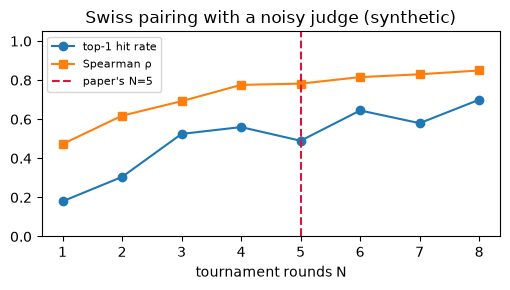

In [22]:
md("**Does N rounds of Swiss recover the true order?** A synthetic judge picks the better of two proposals with "
   "probability `sigmoid(quality gap / noise)`; 200 trials per setting, using the repo's `swiss_pairs`. This is "
   "the paper's Table 1 question (how many rounds to buy) asked of the pairing rule in isolation.")
truth = [1.0, 0.85, 0.7, 0.6, 0.45, 0.3, 0.2, 0.0]
sim_rows = [X.simulate_tournament(truth, rounds=r, noise=0.25, trials=200, seed=r) for r in range(1, 9)]
display(df(sim_rows).set_index("rounds"))
fig, ax = plt.subplots(figsize=(5.2, 3))
ax.plot([r["rounds"] for r in sim_rows], [r["top-1 hit rate"] for r in sim_rows], "o-", label="top-1 hit rate")
ax.plot([r["rounds"] for r in sim_rows], [r["mean Spearman rho"] for r in sim_rows], "s-", label="Spearman ρ")
ax.axvline(5, color="crimson", ls="--", label="paper's N=5")
ax.set(xlabel="tournament rounds N", ylabel="", ylim=(0, 1.05),
       title="Swiss pairing with a noisy judge (synthetic)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [23]:
md("**The real judge** — the zero-shot prompt asks which of two proposals was the accepted one:")
show_source(tournament_ranking.better_idea)

**The real judge** — the zero-shot prompt asks which of two proposals was the accepted one:

**better_idea**

```python
@retry.retry(tries=3, delay=2)
def better_idea(idea_1, idea_2, method, openai_client, model, seed, few_shot_demos=None, temperature=0.):
    prompt = "You are a reviewer specialized in Natural Language Processing and Large Language Models. You are given two project summaries. One of them is accepted by a top AI conference (like ICLR or ACL) and the other one is rejected. Your task is to identify the one that has been accepted.\n"
    
    ## zero-shot methods
    if "zero_shot" in method:
        prompt += "The two project proposals are:\n\n" 
        prompt += "paper 1:\n" + format_plan_json(idea_1) + "\n\n"
        prompt += "paper 2:\n" + format_plan_json(idea_2) + "\n\n"
        # prompt += "\nYou can consider factors like novelty, soundness, excitement, and potential impact.\n"
    
        if method == "zero_shot":
            prompt += "Now decide which one is the accepted idea. Directly return a number 1 or 2 and nothing else.\n"
        elif method == "zero_shot_cot":
            prompt += "Now decide which one is the accepted idea. Think step by step by writing a meta-review to compare the strengths and weaknesses of both ideas and explain why one idea is better than the other. After the meta-review, start a new line and directly return a number 1 or 2 to indicate the accepted idea and end the response.\n"
    
    ## few-shot methods
    elif "few_shot" in method:
        prompt += "Here are some examples:\n" + few_shot_demos
        prompt += "\n\nThe two project summaries given to you are:\n\n" 
        prompt += "paper 1:\n" + format_plan_json(idea_1) + "\n\n"
        prompt += "paper 2:\n" + format_plan_json(idea_2) + "\n\n"
        # prompt += "\nYou should consider factors like novelty, soundness, excitement,and potential impact.\n"
        
        if method == "few_shot":
            prompt += "Now decide which one is the accepted idea. Follow the above examples: return a number 1 or 2 and nothing else.\n"
        elif method == "few_shot_cot":
            prompt += "Now decide which one is the accepted idea. Follow the above examples: give a meta-review and score to each paper, and then start a new line and directly return a number 1 or 2 to indicate the accepted idea and end the response.\n"

    # print (prompt)
    prompt_messages = [{"role": "user", "content": prompt}]
    response, cost = call_api(openai_client, model, prompt_messages, temperature=temperature, max_tokens=3000, seed=seed, json_output=False)
    return prompt, response, cost

```

In [24]:
X.set_tag("tournament")
names = list(PROPOSALS); plans = [PROPOSALS[n] for n in names]
t0 = time.time(); calls0 = USAGE.requests
FINAL_SCORES, _ = tournament_ranking.tournament_ranking(
    plans, names, None, "rcp", 2024, "factuality_prompting_method", str(OUT / "ranking"), max_round=ROUNDS)
print(f"\n{ROUNDS} rounds over {len(names)} proposals: {USAGE.requests - calls0} judgments in {time.time()-t0:.0f}s")
per_round = []
for r in range(1, ROUNDS + 1):
    per_round.append(json.loads((OUT / "ranking" / "factuality_prompting_method" / f"round_{r}.json").read_text()))
RANKING = df([{"proposal": n, **{f"after R{r+1}": per_round[r][n] for r in range(ROUNDS)}} for n in names]
             ).sort_values(f"after R{ROUNDS}", ascending=False).set_index("proposal")
display(RANKING)
print("scores start at 1 and can gain at most 1 per round, so the range is [1, 1+N]")

Current round:  1


Current round:  2


Current round:  3


Current round:  4


Current round:  5



5 rounds over 7 proposals: 15 judgments in 27s


,after R1,after R2,after R3,after R4,after R5
proposal,,,,,
Recursive Counterfactual Prompting,2,3,4,5,6
Stochastic Re-Birth Prompting,1,2,3,3,4
Multi-Agent Role-Play with Adversarial Hackers,2,3,3,4,4
Neural-Explicit-Hierarchical Prompting,1,2,3,3,4
Temporal Identity Prompting,1,1,2,3,3
Adversarial Symbiote Prompting,2,2,2,2,3
Benchmark-Driven Meta-Prompting for Factual Calibration,2,2,2,3,3


scores start at 1 and can gain at most 1 per round, so the range is [1, 1+N]


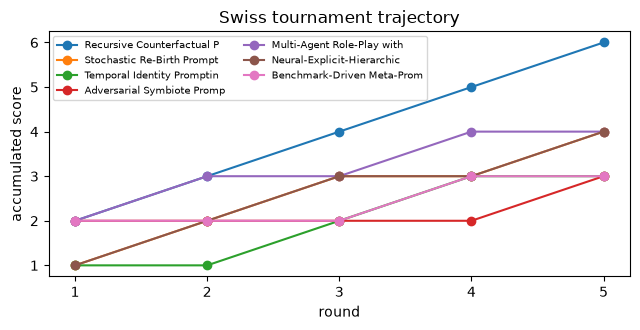

top-ranked:    Recursive Counterfactual Prompting
bottom-ranked: Benchmark-Driven Meta-Prompting for Factual Calibration


In [25]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for n in names:
    ax.plot(range(1, ROUNDS + 1), [per_round[r][n] for r in range(ROUNDS)], "o-", label=n[:26])
ax.set(xlabel="round", ylabel="accumulated score", xticks=range(1, ROUNDS + 1), title="Swiss tournament trajectory")
ax.legend(fontsize=7, ncol=2, loc="upper left"); plt.tight_layout(); plt.show()
TOP, BOTTOM = RANKING.index[0], RANKING.index[-1]
print("top-ranked:   ", TOP)
print("bottom-ranked:", BOTTOM)

### Judge reliability: position consistency

§7.2 (Table 11) reports that this ranker reaches only **53.3%** balanced accuracy against expert reviews — below
the study's own **56.1%** inter-reviewer consistency, and the reason the authors "do not recommend using LLMs as
the evaluator". Without the ICLR labels the cheapest available probe is order sensitivity: run each pair twice
with the proposals swapped and see whether the same one wins.

In [26]:
X.set_tag("judge_consistency")
idx_pairs = [(i, j) for i, j in [(0, 1), (0, len(names) - 1), (1, 2)] if i < j < len(names)]
idx_pairs = list(dict.fromkeys(idx_pairs))[: (2 if QUICK else 3)]
pairs = [(f"{names[i][:18]} vs {names[j][:18]}", PROPOSALS[names[i]], PROPOSALS[names[j]]) for i, j in idx_pairs]
cons = X.position_consistency(pairs, workers=len(pairs))
display(df(cons).set_index("pair"))
n_ok = sum(r["consistent"] for r in cons)
print(f"{n_ok}/{len(cons)} pairs order-consistent  (paper: 53.3% balanced accuracy vs expert reviews, Table 11)")
print("raw replies show whether the model obeyed 'return a number 1 or 2 and nothing else' — the unpatched repo "
      "compares `result.strip() == '1'`, so any extra token silently awards the point to proposal 2.")

,"raw (A,B)","raw (B,A)","winner (A,B)","winner (B,A)",consistent
pair,,,,,
Recursive Counterf vs Stochastic Re-Birt,1,2,A,A,True
Recursive Counterf vs Benchmark-Driven M,1,1,A,B,False
Stochastic Re-Birt vs Temporal Identity,1,1,A,B,False


1/3 pairs order-consistent  (paper: 53.3% balanced accuracy vs expert reviews, Table 11)
raw replies show whether the model obeyed 'return a number 1 or 2 and nothing else' — the unpatched repo compares `result.strip() == '1'`, so any extra token silently awards the point to proposal 2.


### The judge as an agent — one live `pi` session

The pairwise judge is the one place in this pipeline where the paper's component is naturally an *agent* action:
read two competing artefacts, then commit to a decision. Here a short, ephemeral `pi` coding-agent session gets the
two proposals as files in a scratch directory, the repo's own zero-shot instruction as its system prompt, and must
write its verdict to `judgment.json`. It maps onto `tournament_ranking.better_idea` — same inputs, same decision,
but taken by a tool-using agent that has to go and read the material itself.

In [27]:
from utils import format_plan_json
pi_dir = OUT / "pi_judge"; pi_dir.mkdir(exist_ok=True)
(pi_dir / "proposal_1.txt").write_text(format_plan_json(PROPOSALS[TOP]))
(pi_dir / "proposal_2.txt").write_text(format_plan_json(PROPOSALS[BOTTOM]))
print("wrote", [p.name for p in sorted(pi_dir.glob("proposal_*.txt"))],
      [len((pi_dir / f"proposal_{i}.txt").read_text().split()) for i in (1, 2)], "words")

PI_SYSTEM = ("You are a reviewer specialized in Natural Language Processing and Large Language Models. "
             "You are given two project summaries. One of them is accepted by a top AI conference (like ICLR or "
             "ACL) and the other one is rejected. Your task is to identify the one that has been accepted.")
PI_PROMPT = ("Read proposal_1.txt and proposal_2.txt in this directory. Decide which one is the accepted idea, "
             "considering novelty, soundness, excitement and potential impact. Then write judgment.json with "
             "exactly these keys: \"winner\" (the integer 1 or 2), \"novelty\", \"soundness\", \"excitement\" "
             "(one short sentence each comparing the two), and \"rationale\" (two sentences). "
             "Write the file and then stop; do not print the JSON in your reply.")
SESSION = common.run_pi(PI_PROMPT, cwd=pi_dir, tools="read,write", timeout=420,
                        system_prompt=PI_SYSTEM, tag="pi_judge")
SESSION.show()

wrote ['proposal_1.txt', 'proposal_2.txt'] [1114, 1442] words


**pi session** · cwd `/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ideation_study/pi_judge` · 4 turns · 4 tool calls · 7188 in / 1781 out tokens · $0.0015 · 27s · exit 0

> **prompt:** Read proposal_1.txt and proposal_2.txt in this directory. Decide which one is the accepted idea, considering novelty, soundness, excitement and potential impact. Then write judgment.json with exactly these keys: "winner" (the integer 1 or 2), "novelty", "soundness", "excitement" (one short sentence each comparing the two), and "rationale" (two sentences). Write the file and then stop; do not print the JSON in your reply.
- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ideation_study/pi_judge/proposal_1.txt"}
- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ideation_study/pi_judge/proposal_2.txt"}
  - ↩ `Title: Recursive Counterfactual Prompting Reduces Hallucination in Large Language Models
  Problem Statement: Large language models (LLMs) exhibit a strong anchoring bias: once they commit to a factually incorrect claim in a reasoning chain, they rarely backtrack, leading to cascading hallucinations. Existing self-correction methods often fail because the model remains anchored to its initial incorrect trajectory, and the model's own critique is subject to confirmation bias.
  Motivation: Existing methods such as chain-of-thought (CoT), self-refine, and chain-of-verification (CoVe) attempt to …`
  - ↩ `Title: Benchmark-Driven Meta-Prompting: Self-Calibrating LLM Factuality via Confidence-Guided Strategy Selection
  Problem Statement: Large Language Models (LLMs) exhibit highly variable factuality across different knowledge domains—performing reliably on common knowledge (e.g., history) but frequently hallucinating on niche or specialized topics (e.g., law, clinical knowledge). Users currently lack an automated, training-free method to dynamically select an optimal prompting strategy for each input query based on the model's own perceived uncertainty, without requiring external knowledge base…`
- 💬 Now I have both proposals. Let me analyze them carefully before rendering my judgment.

**Proposal 1** (Recursive Counterfactual Prompting) introduces a novel multi-round prompting method where the LLM generates a counterfactual answer assuming its own previous answer is wrong, then cross-examines both to resolve contradictions. It targets the fundamental problem of anchoring bias in LLMs, tests on 4 diverse datasets across 4 models with 5 strong baselines, includes ablation studies, statistical significance testing, and human evaluation with inter-annotator agreement.

**Proposal 2** (Benchma…
- 🔧 `write` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ideation_study/pi_judge/judgment.json", "content": "{\n  \"winner\": 1,\n  \"novelty\": \"Proposal 1 introduces a genuinely creative recursive counterfactual prompting mechanism that forces the model to break out of its own reasoning path, whereas Proposal 2's confidence-guided template selection is a more incremental combination of existing ideas.\",\n  \"soundness\": \"Proposal 1 has a far more rigorous experimental design with multiple datasets, models, strong baselines, statistical testing, and human evaluation, while Proposal 2 …
  - ↩ `Successfully wrote 1393 bytes to /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ideation_study/pi_judge/judgment.json`
- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ideation_study/pi_judge/judgment.json"}
  - ↩ `{
    "winner": 1,
    "novelty": "Proposal 1 introduces a genuinely creative recursive counterfactual prompting mechanism that forces the model to break out of its own reasoning path, whereas Proposal 2's confidence-guided template selection is a more incremental combination of existing ideas.",
    "soundness": "Proposal 1 has a far more rigorous experimental design with multiple datasets, models, strong baselines, statistical testing, and human evaluation, while Proposal 2 relies on a single model, keyword-based domain classification, and weaker baselines.",
    "excitement": "Proposal 1's …`
- 💬 The judgment has been written to `judgment.json`. My analysis concluded that **Proposal 1 (Recursive Counterfactual Prompting)** is the accepted idea. It is substantially more novel (recursive counterfactual reasoning is a creative and theoretically grounded approach to hallucination), more sound (evaluated across 4 datasets, 4 models, 5 strong baselines with statistical testing and human annotation), and more exciting (directly tackles the fundamental problem of anchoring bias in LLMs). Proposal 2, while practically motivated, is more incremental and has notable methodological weaknesses incl…

In [28]:
verdict_file = pi_dir / "judgment.json"
if verdict_file.exists():
    verdict = json.loads(verdict_file.read_text())
    print(json.dumps(verdict, indent=2)[:1600])
    winner = {1: TOP, 2: BOTTOM}.get(int(verdict.get("winner", 0)))
    print(f"\npi picked: {winner}")
    print(f"tournament put {TOP} first and {BOTTOM} last -> pi {'agrees' if winner == TOP else 'disagrees'}")
else:
    print("pi did not write judgment.json; final text was:\n", SESSION.final_text[:800])

{
  "winner": 1,
  "novelty": "Proposal 1 introduces a genuinely creative recursive counterfactual prompting mechanism that forces the model to break out of its own reasoning path, whereas Proposal 2's confidence-guided template selection is a more incremental combination of existing ideas.",
  "soundness": "Proposal 1 has a far more rigorous experimental design with multiple datasets, models, strong baselines, statistical testing, and human evaluation, while Proposal 2 relies on a single model, keyword-based domain classification, and weaker baselines.",
  "excitement": "Proposal 1's recursive counterfactual approach to hallucination mitigation is highly exciting and theoretically grounded in anchoring bias, whereas Proposal 2's meta-prompting via confidence scores is a less impactful and more predictable extension of existing work.",
  "rationale": "Proposal 1 wins because it addresses the fundamental problem of LLM hallucination through a novel, psychologically-motivated recursive c

## 6 · Filtering and style normalisation (Appendix F, Appendix D)

**Filtering.** Appendix F: retrieve the top-10 most relevant papers to a generated proposal and ask the LLM to
compare them one by one; the proposal is dropped as long as *any* retrieved paper is judged equivalent. The repo
adds four cheaper self-checks that run first — consistency (does a "black-box prompting" method secretly need
model internals?), feasibility (does it require building a dataset from scratch?), significance, relevance. The
paper reports the whole filter "filtered out about 1% of the generated project proposals".

**Style normalisation** (§2 *Idea Writeup*, Appendix D). All three conditions were rewritten into one house style
before review, because "there may be subtle writing style cues that affect the outcome measure. For example,
humans may tend to write in a more engaging and informal tone." The prompt is a hard format-transfer: only
wording, punctuation, indentation and bullet structure may change; sections numbered 1–6 after an unindexed title;
the fallback plan condensed into one paragraph; numeric citations stripped, author-name citations kept; model
names normalised (any Claude → Claude-3.5, any LLaMA → LLaMA-3). The authors validated it twice — expert judges
scored **50%** (chance) at telling AI from human ideas afterwards, and the first author manually verified that no
content was lost.

In [29]:
import filter_ideas
X.set_tag("filter")
checks = [("consistency", filter_ideas.consistency_score), ("feasibility", filter_ideas.feasibility_score),
          ("significance", filter_ideas.significance_score)]
rows, verdicts = [], {}
for name in list(PROPOSALS)[: (2 if QUICK else 3)]:
    plan = PROPOSALS[name]; row = {"proposal": name}
    for label, fn in checks:
        _, response, _ = fn(plan, None, "rcp", 2024)
        row[label] = "pass" if X.yes_no(response) else "FAIL"
        verdicts[(name, label)] = response
    _, response, _ = filter_ideas.relevance_score(plan, TOPIC, None, "rcp", 2024)
    row["relevance"] = "pass" if X.yes_no(response) else "FAIL"
    verdicts[(name, "relevance")] = response
    rows.append(row)
display(df(rows).set_index("proposal"))
k = list(verdicts)[0]
print(f"\nrationale for {k[0]!r} / {k[1]}:\n{textwrap.fill(verdicts[k], 110)[:1100]}")

,consistency,feasibility,significance,relevance
proposal,,,,
Recursive Counterfactual Prompting,pass,pass,pass,pass
Stochastic Re-Birth Prompting,pass,pass,pass,pass
Temporal Identity Prompting,pass,pass,pass,pass



rationale for 'Recursive Counterfactual Prompting' / consistency:
The proposed method, Recursive Counterfactual Prompting (RCP), is entirely based on prompting black-box models
(GPT-3.5, GPT-4, Claude-3, and LLaMA-2-70B-chat). All steps—initial answer generation, counterfactual
generation, cross-examination, and recursion—are implemented via API calls or standard inference without
requiring any white-box access such as model weights, embeddings, activations, gradients, or training. The
experiments are feasible: they use publicly available datasets (HotpotQA, 2WikiMultihopQA, TempLAMA,
PubMedQA), standard evaluation metrics (EM, F1, accuracy), and manual annotation for hallucination rate. No
infeasible steps (e.g., generating images) are proposed.  yes


In [30]:
md("**Retrieval-based novelty check** (Appendix F): compare the top-ranked proposal against the most relevant "
   "papers from the §1 bank, one at a time. Any \"Yes\" (same problem *and* same approach) kills the proposal.")
X.set_tag("novelty_check")
rows = []
for paper in PAPER_BANK[: (3 if QUICK else 5)]:
    _, response, _ = filter_ideas.retrieve_novelty_score(PROPOSALS[TOP], paper, None, "rcp", 2024)
    same = X.yes_no(response)
    rows.append({"related paper": (paper.get("title") or "")[:60], "score": paper.get("score"),
                 "same idea?": "YES -> filtered" if same else "no", "reason": response.strip().splitlines()[0][:90]})
display(df(rows).set_index("related paper"))
print(f"proposal {TOP!r}:", "FILTERED" if any("YES" in r["same idea?"] for r in rows) else "passes the novelty check against these papers")
print("note: filter_ideas.all_checks() references `paper_bank` in its return statement even when "
      "retrieve_novelty_check=False, so the individual checks are called directly here.")

**Retrieval-based novelty check** (Appendix F): compare the top-ranked proposal against the most relevant papers from the §1 bank, one at a time. Any "Yes" (same problem *and* same approach) kills the proposal.

,score,same idea?,reason
related paper,,,
KG-CoT: Chain-of-Thought Prompting of Large Language Models,8,no,The proposed research problem is reducing hall...
Adaptive heterogeneous multi-agent debate for enhanced educa,8,no,The proposed research problem is reducing hall...
Aligning Medical Images and Language Through Multimodal Medi,7,no,The proposed research problem is reducing hall...
CSMAD: Hallucination Detection via Multi-Agent Debate with N,7,no,The proposed research problem is reducing hall...
Retrieval-Augmented Large Language Models for Robust Context,6,no,The proposed research problem is reducing hall...


proposal 'Recursive Counterfactual Prompting': passes the novelty check against these papers
note: filter_ideas.all_checks() references `paper_bank` in its return statement even when retrieve_novelty_check=False, so the individual checks are called directly here.


In [31]:
import style_transfer
show_source(style_transfer.style_transfer)

**style_transfer**

```python
@retry.retry(tries=3, delay=2)
def style_transfer(model_idea, human_idea, openai_client, model, seed):
    prompt = "You are a writing assistant specialized in editing academic writing.\n"
    prompt += "I will give you a student's research idea and an idea template. Your task is to edit the student's idea to follow the template's format.\n"
    prompt += "Student idea:\n" + human_idea + "\n\n"
    prompt += "Template:\n" + model_idea + "\n\n"
    prompt += "Make sure that you only edit the wording and formatting, including things like punctuation, capitalization, linebreaks, and bullet points. Also make sure to edit any informal wording and phrasing to use vocabulary that sounds like the template's writing style. No other changes are allowed beyond these.\n"
    prompt += "The main sections should be indexed clearly without indentation at the beginning. The title section does not need indexing, other sections including problem statement, motivation, proposed method, step-by-step experiment plan, test case examples, and fallback plan should be indexed 1 to 6. Each section can then have sub-bullets for sub-sections if applicable. Leave an empty line after each section.\n"
    prompt += "You should use tab as indentation, and make sure to use appropriate nested indentation for sub-bullets. All bullets should have a clear hierarchy so people can easily differetiate the sub-bullets. Only leave empty lines between sections and remove any extra linebreaks. If many bullets points are clustered together in a paragraph, separate them clearly with indentation and appropriate bullet point markers. Change to a new line for each new bullet point.\n"
    prompt += "For the fallback plan, do not list a bunch of bullet points. Instead, condense them into one coherent paragraph.\n"
    prompt += "For linebreaks, avoid Raw String Literals or Double Backslashes when using \"\\n\", change them to spaces or tabs.\n"
    prompt += "For in-line citations, if the citation mentioned the author's last name (like \"(Si et al., 2023)\" or \"(An et al., 2024)\"), you should keep them there; but if the citation is just a number (like \"[1]\" or \"[3,4,5]\"), you should just remove it and do some necessary rephrasing to make the sentence still sound coherent without the references.\n"
    prompt += "Apart from minor rephrasing and changing formatting, do not change any content of the idea. You must preserve the exact meaning of the original idea, do not change, remove or add any other details. Do not drop any sections (including test case examples). Do not rename any models, datasets, or methods. Do not drop clarification or examples in brackets and do not drop any data source mentions (e.g., Chatbot Arena or Wildchat)! Note that when indexing test case examples, each test case example could have multiple steps of inputs and outputs and you shouldn't give separate indices to them. Each test case example should be a whole set of input-output pairs for the baseline(s) and proposed method.\n"
    prompt += "For the proposed method section, avoid any big changes. If the section comes in as a coherent paragraph, you don't have to break it down into bullet points. If the section is already in bullet points, you should keep it that way. If the section is a mix of both, you should keep the bullet points and the coherent paragraph as they are.\n"
    prompt += "Keep all the clarification and examples mentioned in all the sections and do not remove any of them (including those in brackets).\n"
    prompt += "For model selection, if any version of Claude is mentioned, change it to the latest version of Claude (Claude-3.5); if any version of LLaMA is mentioned, change it to the latest version LLaMA-3. Do not make any other model changes.\n"
    prompt += "Now directly generate the edited student idea to match the format of the template:\n"
    
    prompt_messages = [{"role": "user", "content": prompt}]
    response, cost = call_api(openai_client, model, prompt_messages, temperature=0., max_tokens=4096, seed=seed, json_output=False)
    return prompt, response, cost

```

In [32]:
X.set_tag("style_transfer")
MACHINE_TEMPLATE = (PROMPTS / "machine_idea.txt").read_text()
HUMAN_IDEA = (PROMPTS / "human_idea.txt").read_text()
print(f"template (machine style): {len(MACHINE_TEMPLATE.split())} words | "
      f"student idea (human style): {len(HUMAN_IDEA.split())} words\n")
t0 = time.time()
_, NORMALISED, _ = style_transfer.style_transfer(MACHINE_TEMPLATE, HUMAN_IDEA, None, "rcp", 2024)
print(f"normalised in {time.time()-t0:.0f}s -> {len(NORMALISED.split())} words "
      f"({100*len(NORMALISED.split())/len(HUMAN_IDEA.split()):.0f}% of the original length)")
(OUT / "style_before.txt").write_text(HUMAN_IDEA); (OUT / "style_after.txt").write_text(NORMALISED)

template (machine style): 1022 words | student idea (human style): 1162 words



normalised in 51s -> 1162 words (100% of the original length)


8135

In [33]:
md("**Before / after** on the repo's shipped human idea (`prompts/human_idea.txt`):")
print("=" * 46, "BEFORE", "=" * 46); print(HUMAN_IDEA[:1800])
print("\n" + "=" * 46, "AFTER ", "=" * 46); print(NORMALISED[:1800])

**Before / after** on the repo's shipped human idea (`prompts/human_idea.txt`):

============================================== BEFORE ==============================================
Title: Privacy-Preserving Prompt Filtering: Enabling Large Language Models to Protect Sensitive Information
Problem Statement: "Large Language Models (LLMs) can generate outputs that reveal sensitive information about the training data or the individuals represented in it, raising significant privacy concerns in domains such as healthcare, finance, and personal communication.",
Motivation: "Existing approaches to preserving privacy in LLMs, such as differential privacy, federated learning, and post-processing techniques like text sanitization, often require significant computational overhead and can degrade the model's utility. We propose a novel prompting strategy that enables LLMs to filter out privacy-sensitive information from their outputs, without the need for expensive training techniques or post-processing. By leveraging the model's language understanding capabilities, we aim to

In [34]:
import difflib
before_w, after_w = HUMAN_IDEA.split(), NORMALISED.split()
sm = difflib.SequenceMatcher(None, before_w, after_w)
kept = sum(b.size for b in sm.get_matching_blocks())
display(df([{"metric": "words before", "value": len(before_w)},
            {"metric": "words after", "value": len(after_w)},
            {"metric": "words preserved verbatim (longest-match)", "value": kept},
            {"metric": "content overlap (kept / before)", "value": round(kept / len(before_w), 3)},
            {"metric": "numbered sections 1.–6. present after", "value": sum(f"\n{i}." in NORMALISED or f"{i}. " in NORMALISED for i in range(1, 7))},
            {"metric": "numeric citations [n] remaining", "value": len([m for m in NORMALISED.split() if m.startswith("[") and m[1:-1].replace(",", "").isdigit()])}]).set_index("metric"))
print("the paper's own check was manual: the first author verified every normalised human idea kept its content, "
      "and expert judges then scored 50% (chance) at telling AI from human ideas.")

,value
metric,
words before,1162.000
words after,1162.000
words preserved verbatim (longest-match),1042.000
content overlap (kept / before),0.897
numbered sections 1.–6. present after,6.000
numeric citations [n] remaining,0.000


the paper's own check was manual: the first author verified every normalised human idea kept its content, and expert judges then scored 50% (chance) at telling AI from human ideas.


## 7 · Mini end-to-end pipeline on a second topic

The six modules chained on a fresh topic — **Uncertainty**, one of the paper's seven — at the smallest budget that
still exercises every stage: retrieve → generate → dedup → expand → rank → filter.

In [35]:
E2E_TOPIC = X.TOPICS["Uncertainty"]
e2e_papers, e2e_batches, e2e_rounds, e2e_props = (8, 1, 2, 2) if QUICK else (10, 1, 3, 4)
stages, t_start, calls_start = [], time.time(), USAGE.requests

X.set_tag("e2e_lit_review")
t0 = time.time(); c0 = USAGE.requests
bank2, _, queries2 = lit_review.collect_papers(E2E_TOPIC, None, "rcp", 2024, grounding_k=5,
                                               max_papers=e2e_papers, print_all=False, mode="topic")
stages.append({"stage": "1 related-paper search", "output": f"{len(bank2)} papers, {len(queries2)} queries",
               "calls": USAGE.requests - c0, "s": round(time.time() - t0)})

X.set_tag("e2e_idea_gen")
t0 = time.time(); c0 = USAGE.requests
batches2 = X.generate_seed_ideas(bank2, DEMOS, E2E_TOPIC, n_batches=e2e_batches, ideas_n=5,
                                 grounding_k=5, max_tokens=6000, workers=e2e_batches)
names2, values2 = X.flatten_ideas(batches2)
stages.append({"stage": "2 grounded idea generation", "output": f"{len(names2)} seed ideas",
               "calls": USAGE.requests - c0, "s": round(time.time() - t0)})

t0 = time.time()
texts2, names2, values2, _ = X.concat_ideas(names2, values2)
sim2, backend2 = utils.rcp_similarity_matrix(texts2)
kept2, _ = dedup_ideas.dedup_ideas(texts2, names2, values2, sim2, similarity_threshold=SIM_THRESHOLD)
stages.append({"stage": "3 deduplication (0.8)", "output": f"{len(kept2)}/{len(names2)} survive ({backend2})",
               "calls": 0, "s": round(time.time() - t0)})

[S2] status 429, retry 1/8 in 1.5s


[S2] status 429, retry 2/8 in 2.7s


[S2] status 429, retry 3/8 in 4.3s


[S2] status 429, retry 4/8 in 8.9s


[S2] status 429, retry 5/8 in 16.4s


...

[S2] status 429, retry 2/8 in 2.8s


[S2] status 429, retry 3/8 in 4.1s


[S2] status 429, retry 4/8 in 8.4s


[S2] status 429, retry 5/8 in 16.3s


[S2] status 429, retry 6/8 in 30.9s


In [36]:
X.set_tag("e2e_proposal_gen")
t0 = time.time(); c0 = USAGE.requests
props2 = X.generate_proposals(dict(list(kept2.items())[:e2e_props]), PLAN_DEMOS, E2E_TOPIC, workers=e2e_props)
stages.append({"stage": "4 proposal generation", "output": f"{len(props2)} proposals",
               "calls": USAGE.requests - c0, "s": round(time.time() - t0)})

X.set_tag("e2e_tournament")
t0 = time.time(); c0 = USAGE.requests
n2 = list(props2)
if len(n2) >= 2:
    scores2, _ = tournament_ranking.tournament_ranking([props2[n] for n in n2], n2, None, "rcp", 2024,
                                                       "uncertainty_prompting_method", str(OUT / "ranking"),
                                                       max_round=e2e_rounds)
else:
    scores2 = [1] * len(n2)
ranked2 = sorted(zip(n2, scores2), key=lambda t: -t[1])
stages.append({"stage": f"5 ranking ({e2e_rounds} Swiss rounds)", "output": f"top: {ranked2[0][0]} ({ranked2[0][1]})",
               "calls": USAGE.requests - c0, "s": round(time.time() - t0)})

X.set_tag("e2e_filter")
t0 = time.time(); c0 = USAGE.requests
best2 = props2[ranked2[0][0]]
passed = []
for label, fn in [("consistency", filter_ideas.consistency_score), ("feasibility", filter_ideas.feasibility_score),
                  ("significance", filter_ideas.significance_score)]:
    _, resp, _ = fn(best2, None, "rcp", 2024)
    passed.append(f"{label}={'pass' if X.yes_no(resp) else 'FAIL'}")
stages.append({"stage": "6 filtering", "output": ", ".join(passed),
               "calls": USAGE.requests - c0, "s": round(time.time() - t0)})

display(df(stages).set_index("stage"))
print(f"\nend-to-end: {USAGE.requests - calls_start} LLM calls, {time.time()-t_start:.0f}s")
print(f"\nWinning proposal for '{E2E_TOPIC[:60]}...':\n  {ranked2[0][0]}")
print(textwrap.fill(str(best2.get("Problem Statement") or next((v for v in best2.values() if isinstance(v, str)), best2)), 110)[:900])

Current round:  1


Current round:  2


Current round:  3


,output,calls,s
stage,,,
1 related-paper search,"19 papers, 11 queries",11,996
2 grounded idea generation,5 seed ideas,1,30
3 deduplication (0.8),5/5 survive (openai/text-embedding-3-small),0,1
4 proposal generation,4 proposals,4,878
5 ranking (3 Swiss rounds),top: Entropy-Guided Recursive Decomposition Pr...,6,7
6 filtering,"consistency=pass, feasibility=pass, significan...",3,57



end-to-end: 25 LLM calls, 1968s

Winning proposal for 'novel prompting methods that can better quantify uncertainty...':
  Entropy-Guided Recursive Decomposition Prompting
Large language models (LLMs) frequently produce overconfident yet incorrect answers on ambiguous or multi-
faceted questions, and standard confidence scores (e.g., token probabilities, verbalized confidence) provide
only a single, coarse confidence score for the entire answer, failing to identify which specific sub-component
of the reasoning the model is uncertain about. This lack of fine-grained uncertainty decomposition limits the
interpretability and trustworthiness of LLM outputs in high-stakes applications such as medical diagnosis,
legal reasoning, and multi-hop question answering. The problem is important because users cannot tell whether
the model is unsure about a factual premise, a logical step, or a numerical calculation, leading to misplaced
trust or over-reliance on flawed answers.


## 8 · The human study itself (§5, Tables 7–8) — reproduced from the shipped data

The repo ships `reviews_ideation/data_points_all_anonymized.json`: every numerical score and free-text rationale
from the study (79 reviewers, 49 ideas per condition), plus the scripts used for the significance tests. This is
the headline result of the paper and it costs nothing to reproduce.

* **Conditions:** `Human` (expert-written), `AI` (top-ranked by the agent above), `AI_Rerank` (the first author
  picked the best of the agent's generations by hand).
* **Test 1** (§5.1, Table 7): each review is a datapoint. **Test 2** (§5.2, Table 8): scores averaged per idea
  first, so each idea is a datapoint.
* Both use two-tailed **Welch's t-tests** against the `Human` condition with **Bonferroni** correction over the
  five metrics. `stats_overall.py` gets the correction from `statsmodels.multipletests`; `X.welch_table` writes it
  out as `min(p·m, 1)` so no extra dependency is needed.

In [37]:
REVIEWS = X.human_study_frame(VENDOR)
print(f"{len(REVIEWS)} reviews, {REVIEWS.idea_id.nunique()} distinct ideas, "
      f"{REVIEWS.topic.nunique()} topics; conditions: {REVIEWS.condition.value_counts().to_dict()}")
display(REVIEWS[["topic", "condition", "idea_id", "novelty_score", "excitement_score",
                 "feasibility_score", "effectiveness_score", "overall_score", "confidence_score"]].head(5))

337 reviews, 147 distinct ideas, 7 topics; conditions: {'Human': 119, 'AI': 109, 'AI_Rerank': 109}


,topic,condition,idea_id,novelty_score,excitement_score,feasibility_score,effectiveness_score,overall_score,confidence_score
0,Multilingual,AI,Multilingual_9 _AI,3,3,7,1,1,5
1,Multilingual,AI,Multilingual_9 _AI,5,2,7,3,2,1
2,Factuality,AI,Factuality_1 _AI,1,2,8,3,2,4
3,Factuality,AI,Factuality_1 _AI,2,3,8,10,2,5
4,Bias,AI_Rerank,Bias_1 _AI_Rerank,6,5,4,5,4,3


In [38]:
md("**Test 1 — each review is a datapoint (paper Table 7).** Cells are mean ± SD on the 1–10 review scale.")
display(df(X.welch_table(REVIEWS)).set_index("metric"))
md("**Paper Table 7 (for comparison):** novelty Human 4.84 / AI 5.64 (p=0.00) / AI+Rerank 5.81 (p=0.00); "
   "excitement 4.55 / 5.19 (p=0.04) / 5.46 (p=0.00); feasibility 6.61 / 6.34 / 6.44 (both p=1.00); "
   "effectiveness 5.13 / 5.47 (p=0.67) / 5.55 (p=0.29); overall 4.68 / 4.85 (p=1.00) / 5.34 (p=0.04).")

**Test 1 — each review is a datapoint (paper Table 7).** Cells are mean ± SD on the 1–10 review scale.

,Human (119),AI (109),AI+Rerank (109),p (AI vs Human),p (Rerank vs Human)
metric,,,,,
novelty,4.84 ± 1.79,5.64 ± 1.76,5.81 ± 1.66,0.0041,0.0002
excitement,4.55 ± 1.89,5.19 ± 1.73,5.46 ± 1.82,0.0430,0.0015
feasibility,6.61 ± 1.99,6.34 ± 1.88,6.44 ± 1.63,1.0000,1.0000
effectiveness,5.13 ± 1.76,5.47 ± 1.58,5.55 ± 1.52,0.6742,0.2921
overall,4.68 ± 1.90,4.85 ± 1.70,5.34 ± 1.79,1.0000,0.0386


**Paper Table 7 (for comparison):** novelty Human 4.84 / AI 5.64 (p=0.00) / AI+Rerank 5.81 (p=0.00); excitement 4.55 / 5.19 (p=0.04) / 5.46 (p=0.00); feasibility 6.61 / 6.34 / 6.44 (both p=1.00); effectiveness 5.13 / 5.47 (p=0.67) / 5.55 (p=0.29); overall 4.68 / 4.85 (p=1.00) / 5.34 (p=0.04).

In [39]:
md("**Test 2 — each idea is a datapoint (paper Table 8).** Scores are averaged within an idea first, so each "
   "condition contributes exactly 49 points and reviewer-level correlation is removed.")
PER_IDEA = REVIEWS.groupby(["idea_id", "condition"], as_index=False)[X.METRICS].mean()
display(df(X.welch_table(PER_IDEA)).set_index("metric"))
md("**Paper Table 8:** novelty 4.86 / 5.62 (p=0.03) / 5.78 (p=0.00); excitement 4.56 / 5.18 (p=0.08) / "
   "5.45 (p=0.00); feasibility 6.53 / 6.30 / 6.41; effectiveness 5.10 / 5.48 / 5.57; overall 4.69 / 4.83 / 5.32.")

**Test 2 — each idea is a datapoint (paper Table 8).** Scores are averaged within an idea first, so each condition contributes exactly 49 points and reviewer-level correlation is removed.

,Human (49),AI (49),AI+Rerank (49),p (AI vs Human),p (Rerank vs Human)
metric,,,,,
novelty,4.86 ± 1.26,5.62 ± 1.39,5.78 ± 1.07,0.0313,0.0011
excitement,4.56 ± 1.16,5.18 ± 1.33,5.45 ± 1.36,0.0783,0.0043
feasibility,6.53 ± 1.50,6.30 ± 1.27,6.41 ± 1.06,1.0000,1.0000
effectiveness,5.10 ± 1.14,5.48 ± 1.23,5.57 ± 1.00,0.5842,0.1692
overall,4.69 ± 1.16,4.83 ± 1.34,5.32 ± 1.24,1.0000,0.0567


**Paper Table 8:** novelty 4.86 / 5.62 (p=0.03) / 5.78 (p=0.00); excitement 4.56 / 5.18 (p=0.08) / 5.45 (p=0.00); feasibility 6.53 / 6.30 / 6.41; effectiveness 5.10 / 5.48 / 5.57; overall 4.69 / 4.83 / 5.32.

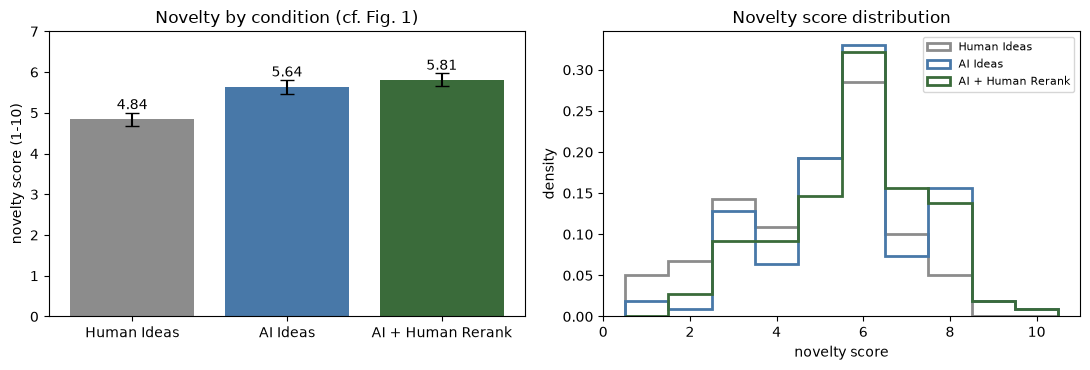

novelty: AI ideas score +0.80 over human ideas, AI + human rerank +0.97 — the paper's headline claim.
feasibility moves the other way and is not significant; §6.2 notes reviewers weight novelty and excitement heavily (overall correlates r=0.725 with novelty but only r=0.097 with feasibility).


In [40]:
X.plot_novelty(REVIEWS)
best = REVIEWS.groupby("condition")["novelty_score"].mean()
print(f"novelty: AI ideas score {best['AI'] - best['Human']:+.2f} over human ideas, "
      f"AI + human rerank {best['AI_Rerank'] - best['Human']:+.2f} — the paper's headline claim.")
print("feasibility moves the other way and is not significant; §6.2 notes reviewers weight novelty and "
      "excitement heavily (overall correlates r=0.725 with novelty but only r=0.097 with feasibility).")

In [41]:
md("**Per-topic breakdown (Appendix O)** — novelty means by topic and condition; the aggregate effect is not "
   "uniform across the seven topics, and the Factuality topic used in §1–§6 above is one of the weaker ones.")
pivot = REVIEWS.pivot_table(index="topic", columns="condition", values="novelty_score", aggfunc="mean").round(2)
pivot["n reviews"] = REVIEWS.groupby("topic").size()
display(pivot)

**Per-topic breakdown (Appendix O)** — novelty means by topic and condition; the aggregate effect is not uniform across the seven topics, and the Factuality topic used in §1–§6 above is one of the weaker ones.

condition,AI,AI_Rerank,Human,n reviews
topic,,,,
Bias,5.89,5.60,4.00,28
Coding,5.50,5.60,5.23,62
Factuality,4.85,5.46,4.75,82
Math,5.00,6.00,4.50,24
Multilingual,6.95,6.18,4.59,65
Safety,6.20,6.30,4.92,32
Uncertainty,5.20,5.80,5.50,44


## Summary

In [42]:
summary = [
 {"§": 1, "block": "Related-paper search (§3.1)",
  "what this run showed": f"{len(PAPER_BANK)} papers via {len(ALL_QUERIES)} LLM-proposed S2 queries; all three actions executed; 1–10 rerank scores"},
 {"§": 2, "block": "Grounded idea generation (§3.2)",
  "what this run showed": f"{len(NAMES)} seed ideas in {N_BATCHES} batches, RAG on half, seed-idea JSON format verbatim"},
 {"§": 3, "block": "Deduplication at 0.8 (§3.2, §7.1)",
  "what this run showed": f"{len(KEPT)}/{len(TEXTS)} survive with {BACKEND}; threshold sweep + hand-built near-duplicates; repo CLI reproduced"},
 {"§": 4, "block": "Proposal generation (App. B)",
  "what this run showed": f"{len(PROPOSALS)} full 7-section proposals, mean {int(np.mean([len(json.dumps(p).split()) for p in PROPOSALS.values()]))} words (paper: 1186.3)"},
 {"§": 5, "block": "Swiss tournament ranking (§3.3)",
  "what this run showed": f"pairing rule verified on synthetic scores; {ROUNDS} real rounds over {len(names)} proposals; {sum(r['consistent'] for r in cons)}/{len(cons)} order-consistent judgments; 1 pi judge session"},
 {"§": 6, "block": "Filtering + style normalisation (App. F/D)",
  "what this run showed": "consistency/feasibility/significance/relevance verdicts + per-paper novelty check; before/after style transfer with content-overlap measurement"},
 {"§": 7, "block": "End-to-end (§3)",
  "what this run showed": f"all six modules chained on the Uncertainty topic; winner: {ranked2[0][0]}"},
 {"§": 8, "block": "Human study (§5, Tables 7–8)",
  "what this run showed": "Tables 7 and 8 reproduced exactly from the shipped reviews: AI ideas rated significantly more novel than expert ideas"},
]
display(df(summary).set_index("§"))

,block,what this run showed
§,,
1,Related-paper search (§3.1),37 papers via 8 LLM-proposed S2 queries; all t...
2,Grounded idea generation (§3.2),"19 seed ideas in 4 batches, RAG on half, seed-..."
3,"Deduplication at 0.8 (§3.2, §7.1)",9/19 survive with openai/text-embedding-3-smal...
4,Proposal generation (App. B),"7 full 7-section proposals, mean 1842 words (p..."
5,Swiss tournament ranking (§3.3),pairing rule verified on synthetic scores; 5 r...
6,Filtering + style normalisation (App. F/D),consistency/feasibility/significance/relevance...
7,End-to-end (§3),all six modules chained on the Uncertainty top...
8,"Human study (§5, Tables 7–8)",Tables 7 and 8 reproduced exactly from the shi...


**Caveats.** One topic, ~20 seed ideas and a handful of proposals instead of 4000 seed ideas per topic across
seven topics, on `RCP_MODEL` instead of `claude-3-5-sonnet-20240620`. The deduplication embedding is not the
paper's `all-MiniLM-L6-v2` (it needs torch, reserved elsewhere), so the 0.8 threshold is not calibrated for the
model actually used — the sweep in §3 exists to make that visible. The ICLR-1.2K accept/reject validation set for
the pairwise ranker is not shipped with the repo, so §5 substitutes a synthetic study of the pairing rule plus a
position-consistency probe of the real judge; the paper's own reliability numbers (71.4% pairwise accuracy on
ICLR accept/reject, 53.3% balanced accuracy against expert reviews) are quoted, not reproduced. §8 is the one
section that reproduces the paper's published numbers exactly.

In [43]:
print(USAGE.summary())

88 requests, 324907 in / 65282 out tokens, 3931s in model calls, $0.0535; by tag: {'e2e_filter': 3, 'e2e_idea_gen': 1, 'e2e_lit_review': 11, 'e2e_proposal_gen': 4, 'e2e_tournament': 6, 'filter': 12, 'idea_gen': 5, 'judge_consistency': 6, 'lit_review': 10, 'novelty_check': 5, 'pi_judge': 1, 'proposal_gen': 8, 'style_transfer': 1, 'tournament': 15}
